- Hlavní fair výsledek (25/10 ELSA + 250/50 SAE): winner = X
- Extended budget kontrola (včetně 30/12 ELSA): winner = X (stejný)
- Chtělo by vyfiltrovat od legacy a nechat konzitentní nastavení.

In [1]:
from copy import deepcopy
from pathlib import Path
import json
import matplotlib.pyplot as plt
import os
import polars as pl
import seaborn as sns

plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 14
plt.rcParams["lines.markersize"] = 10

# Path setup aligned with train/recsys26 scripts (util.py -> OUTPUT_ROOT/results)
if "OUTPUT_ROOT" in os.environ:
    _output_root = Path(os.environ["OUTPUT_ROOT"])
elif Path.cwd().name == "results":
    _output_root = Path.cwd().parent
else:
    _output_root = Path.cwd()
RESULTS_ROOT = _output_root / "results"
FIGURES_DIR = Path.cwd() / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# If both aliases exist, pick the one with more JSON files.
def _json_count(ds: str) -> int:
    ds_dir = RESULTS_ROOT / ds
    if not ds_dir.exists():
        return 0
    return len(list(ds_dir.glob("*.json")))

DATASETS = ["ml-32m-filtered"]
selected_dataset = DATASETS[0]

CF_MODELS = ("ELSA",)
SAE_MODELS = ("TopKSAE",)
SPLITS = ["val", "test"]

print(f"Using dataset folder: {selected_dataset}")

Using dataset folder: ml-32m-filtered


In [2]:
result_dataframes = {d: {s: {"cf models": [], "sae models": []} for s in SPLITS} for d in DATASETS}

for dataset in DATASETS:
    dataset_dir = RESULTS_ROOT / dataset
    if not dataset_dir.exists():
        raise FileNotFoundError(f"Results directory not found: {dataset_dir}")

    for results_file in sorted(os.listdir(dataset_dir)):
        if not results_file.endswith(".json"):
            continue

        with open(dataset_dir / results_file, "r", encoding="utf-8") as f:
            d = json.load(f)

        job_cfg = d.get("job_cfg", {})
        results_payload = d.get("results", {})

        for split in SPLITS:
            if split not in results_payload:
                continue

            results_dict = results_payload[split]
            flat_results = {"checkpoint": results_file} | deepcopy(job_cfg)

            # Flatten one-level dict metrics like "metric": {"mean": ..., "se": ...}
            for metric_name, metric_value in results_dict.items():
                if isinstance(metric_value, dict):
                    for k, v in metric_value.items():
                        flat_results[f"{metric_name} {k}"] = v
                else:
                    flat_results[metric_name] = metric_value

            if results_file.startswith(CF_MODELS):
                # CF metrics are nested under @k payloads.
                for topk in ["@10", "@20"]:
                    if topk not in results_dict:
                        continue
                    for metric_name in ["recall", "ndcg"]:
                        payload = results_dict[topk].get(metric_name, {})
                        if isinstance(payload, dict):
                            if "mean" in payload:
                                flat_results[f"{metric_name} mean {topk}"] = payload["mean"]
                            if "se" in payload:
                                flat_results[f"{metric_name} se {topk}"] = payload["se"]

                # Keep compatibility columns used by historical cells (prefer @20).
                preferred_topk = "@20" if "@20" in results_dict else ("@10" if "@10" in results_dict else None)
                if preferred_topk is not None:
                    for metric_name in ["recall", "ndcg"]:
                        payload = results_dict[preferred_topk].get(metric_name, {})
                        if isinstance(payload, dict):
                            if "mean" in payload:
                                flat_results[f"{metric_name} mean"] = payload["mean"]
                            if "se" in payload:
                                flat_results[f"{metric_name} se"] = payload["se"]

                result_dataframes[dataset][split]["cf models"].append(flat_results)

            elif results_file.startswith(SAE_MODELS):
                flat_results["input_dim"] = int(flat_results["pretrained_model_checkpoint"].split("-")[1])
                result_dataframes[dataset][split]["sae models"].append(flat_results)

    for model_type in ["cf models", "sae models"]:
        val_rows = result_dataframes[dataset]["val"][model_type]
        if len(val_rows) == 0:
            result_dataframes[dataset]["val"][model_type] = pl.DataFrame()
        else:
            val_data = {k: [row.get(k) for row in val_rows] for k in val_rows[0].keys()}
            result_dataframes[dataset]["val"][model_type] = pl.DataFrame(val_data)

        test_rows = result_dataframes[dataset]["test"][model_type]
        if len(test_rows) == 0:
            # test_user_ratio=0.0 case: keep downstream cells runnable.
            if result_dataframes[dataset]["val"][model_type].height > 0:
                result_dataframes[dataset]["test"][model_type] = result_dataframes[dataset]["val"][model_type].clone()
            else:
                result_dataframes[dataset]["test"][model_type] = pl.DataFrame()
        else:
            test_data = {k: [row.get(k) for row in test_rows] for k in test_rows[0].keys()}
            result_dataframes[dataset]["test"][model_type] = pl.DataFrame(test_data)

    for split in SPLITS:
        if result_dataframes[dataset][split]["sae models"].height > 0:
            result_dataframes[dataset][split]["sae models"] = (
                result_dataframes[dataset][split]["sae models"]
                .with_columns(
                    pl.when(pl.col("reconstruction_loss") == "Cosine")
                    .then(pl.col("model_class") + " (" + pl.col("reconstruction_loss") + ")")
                    .otherwise(pl.col("model_class"))
                    .alias("model_class")
                )
                .with_columns((pl.col("embedding_dim") / pl.col("input_dim")).cast(pl.Int32).alias("scaling_factor"))
                .with_columns(pl.col("pretrained_model_checkpoint").str.split("-").list.first().alias("cf_model"))
                .with_columns((pl.col("input_dim") / 512).cast(pl.Int32).alias("cf_model_size"))
            )

# Results tables

In [3]:
# results for dataset=ml-32m-filtered, split=val, category="sae models"
result_dataframes[DATASETS[0]]["val"]["sae models"]

# optional: if test split exists
# result_dataframes[DATASETS[0]]["test"]["cf models"]

checkpoint,dataset,pretrained_model_checkpoint,model_module,model_class,embedding_dim,reconstruction_loss,l1_coef,k,epochs,early_stopping,batch_size,lr,beta1,beta2,seed,cosine mean,cosine se,l0 mean,l0 se,dead neurons,recall mean,recall se,recall degradation mean,recall degradation se,ndcg mean,ndcg se,ndcg degradation mean,ndcg degradation se,input_dim,scaling_factor,cf_model,cf_model_size
str,str,str,str,str,i64,str,f64,i64,i64,i64,i64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i32,str,i32
"""TopKSAE-1024-4d51a427.json""","""ml-32m-filtered""","""ELSA-512-c2005bb7.ckpt""","""sae""","""TopKSAE (Cosine)""",1024,"""Cosine""",0.0003,32,250,50,1024,0.0003,0.9,0.99,42,0.866528,0.001362,32.0,0.0,0,0.352038,0.002534,-0.014642,0.000972,0.357929,0.002598,-0.015309,0.000762,512,2,"""ELSA""",1
"""TopKSAE-1024-77965725.json""","""ml-32m-filtered""","""ELSA-512-c2005bb7.ckpt""","""sae""","""TopKSAE (Cosine)""",1024,"""Cosine""",0.0003,64,250,50,1024,0.0003,0.9,0.99,42,0.88896,0.001235,64.0,0.0,0,0.353924,0.002509,-0.011022,0.000865,0.360001,0.002609,-0.010754,0.000658,512,2,"""ELSA""",1
"""TopKSAE-1024-b7aad94c.json""","""ml-32m-filtered""","""ELSA-512-c2005bb7.ckpt""","""sae""","""TopKSAE (Cosine)""",1024,"""Cosine""",0.0003,8,250,50,1024,0.0003,0.9,0.99,42,0.796306,0.001464,8.0,0.0,14,0.319677,0.002462,-0.045661,0.00131,0.325948,0.002548,-0.044411,0.00113,512,2,"""ELSA""",1
"""TopKSAE-1024-f0b0da0a.json""","""ml-32m-filtered""","""ELSA-512-c2005bb7.ckpt""","""sae""","""TopKSAE (Cosine)""",1024,"""Cosine""",0.0003,16,250,50,1024,0.0003,0.9,0.99,42,0.835616,0.001418,16.0,0.0,0,0.339433,0.00249,-0.025905,0.001098,0.344109,0.002571,-0.02625,0.000911,512,2,"""ELSA""",1
"""TopKSAE-16384-1ba448a0.json""","""ml-32m-filtered""","""ELSA-2048-76e4370a.ckpt""","""sae""","""TopKSAE (Cosine)""",16384,"""Cosine""",0.0003,32,250,50,1024,0.0003,0.9,0.99,42,0.798296,0.001705,31.99338,0.002085,1030,0.3407,0.002463,-0.027815,0.00123,0.350058,0.002564,-0.03005,0.001065,2048,8,"""ELSA""",4
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""TopKSAE-8192-c054d5c7.json""","""ml-32m-filtered""","""ELSA-1024-7f035e3d.ckpt""","""sae""","""TopKSAE (Cosine)""",8192,"""Cosine""",0.0003,8,250,50,1024,0.0003,0.9,0.99,42,0.737361,0.001581,8.0,0.0,642,0.31903,0.002485,-0.054499,0.001442,0.324849,0.002534,-0.056787,0.001277,1024,8,"""ELSA""",2
"""TopKSAE-8192-c74a9ecc.json""","""ml-32m-filtered""","""ELSA-2048-76e4370a.ckpt""","""sae""","""TopKSAE (Cosine)""",8192,"""Cosine""",0.0003,64,250,50,1024,0.0003,0.9,0.99,42,0.842487,0.001765,61.225254,0.08426,96,0.35097,0.002489,-0.021391,0.00112,0.358844,0.002566,-0.022868,0.00098,2048,4,"""ELSA""",4
"""TopKSAE-8192-e626099b.json""","""ml-32m-filtered""","""ELSA-1024-7f035e3d.ckpt""","""sae""","""TopKSAE (Cosine)""",8192,"""Cosine""",0.0003,32,250,50,1024,0.0003,0.9,0.99,42,0.820944,0.00166,31.999353,0.000511,157,0.347533,0.002509,-0.025289,0.001162,0.357555,0.00259,-0.024963,0.000976,1024,8,"""ELSA""",2


# Validation results

## Sparsity vs downstream accuracy

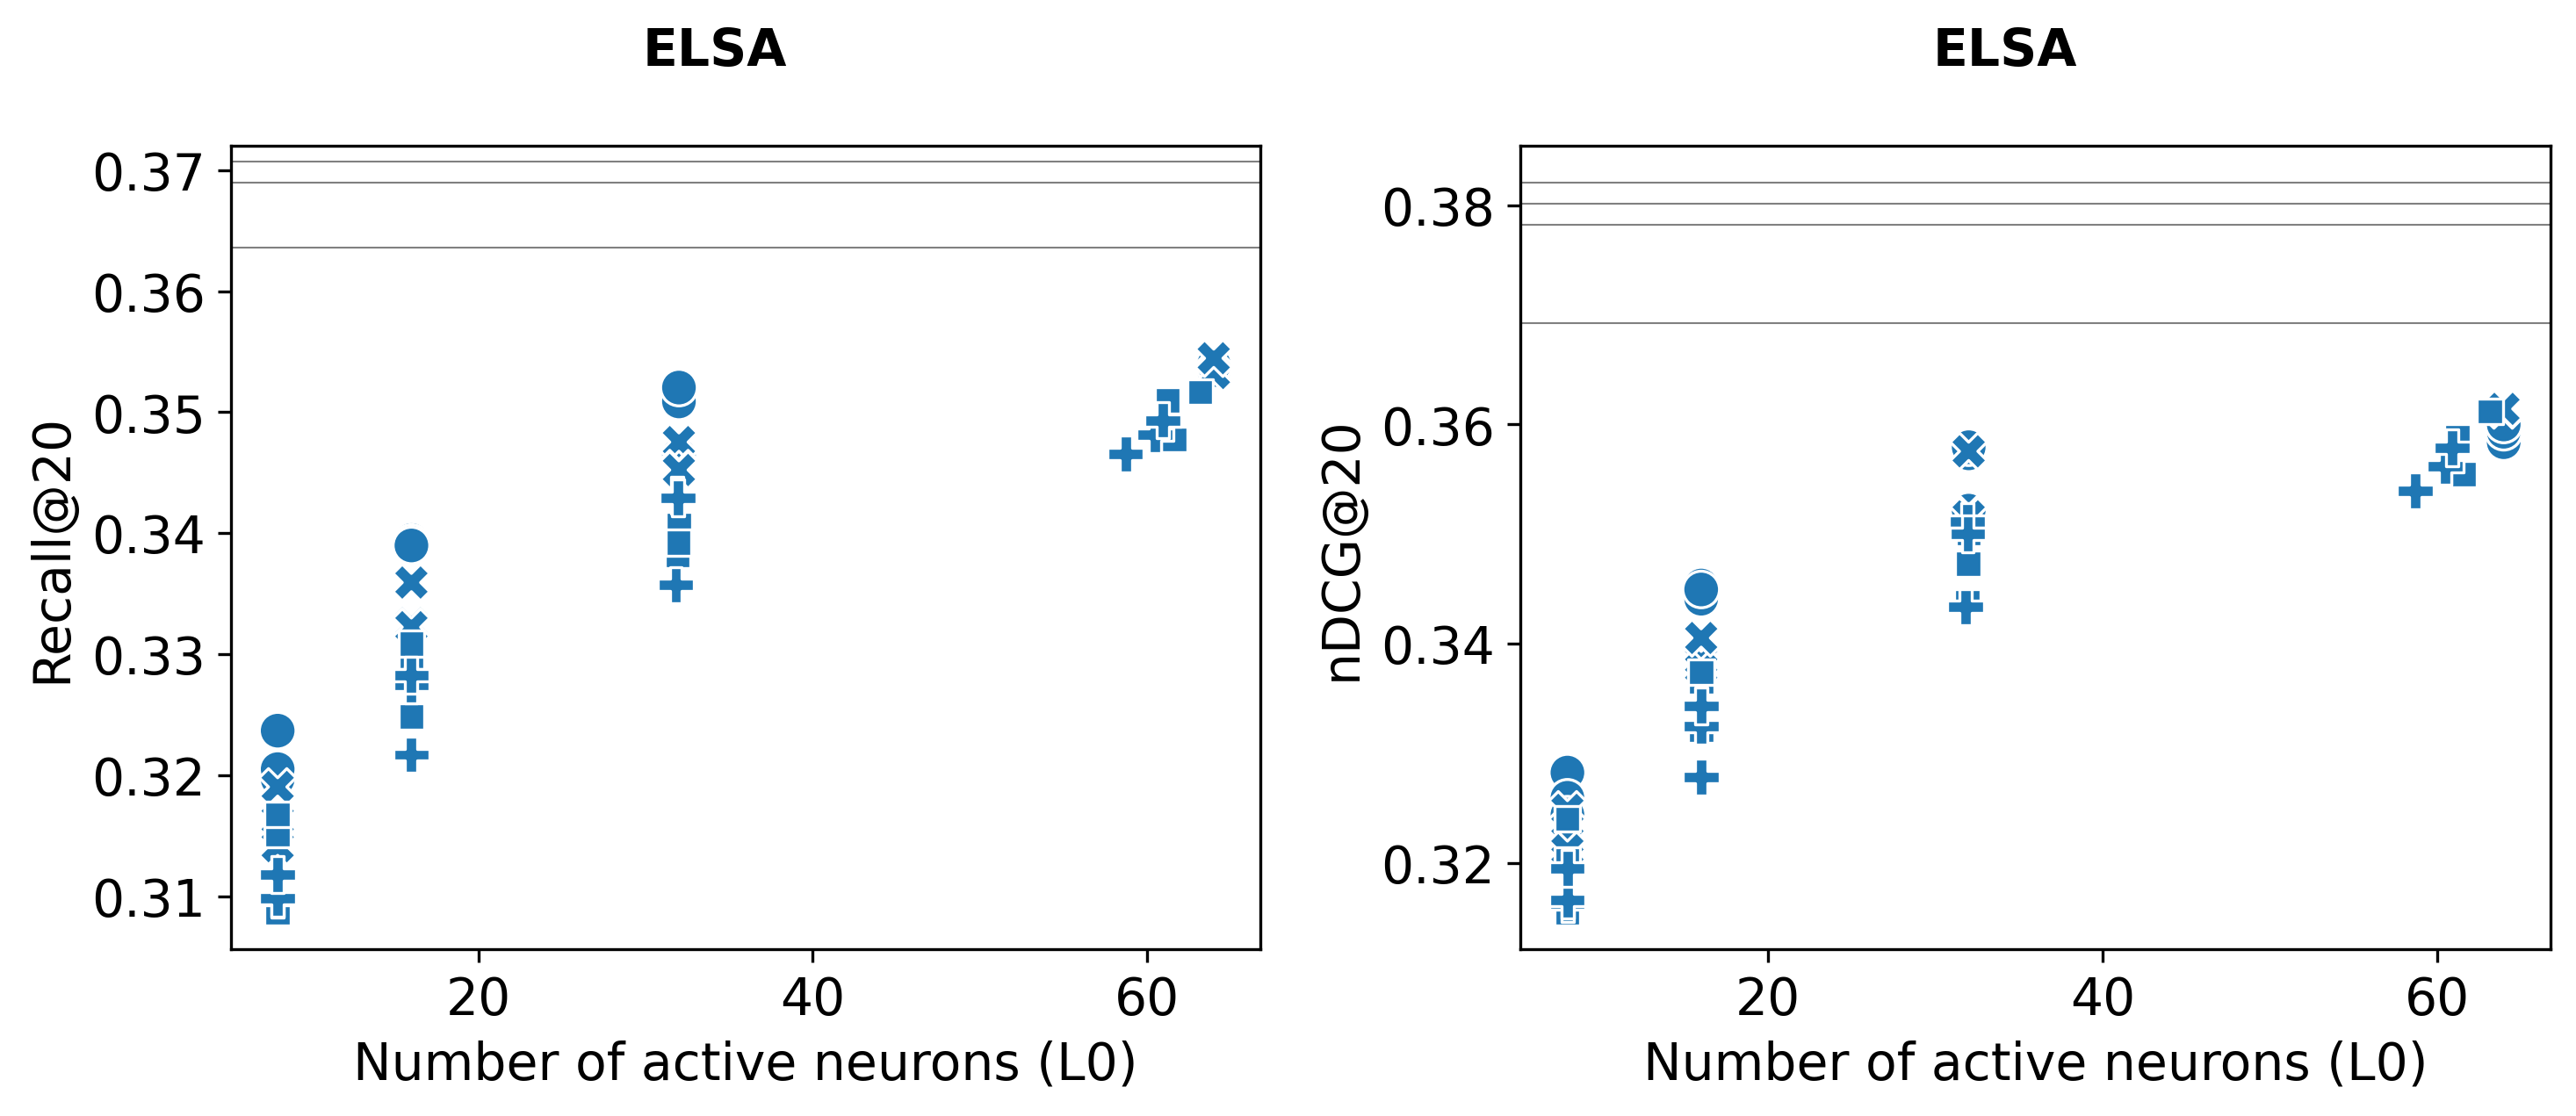

In [4]:
n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), squeeze=False)

for i, dataset in enumerate(DATASETS):
    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join([exp[0], "mean"])
        sns.scatterplot(
            result_dataframes[dataset]["val"]["sae models"]
            .filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))
            .sort(by=["model_class", "cf_model_size"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="cf_model_size",
            ax=ax,
            legend=False,
        )
        for row in result_dataframes[dataset]["val"]["cf models"].filter(pl.col("model_class") == exp[1]).iter_rows(named=True):
            ax.axhline(y=row[y], color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("Recall@20" if y.startswith("recall") else "nDCG@20")

for j, exp in enumerate(columns):
    axes[0, j].annotate(exp[1], xy=(0.4, 1.1), xycoords="axes fraction", fontsize=14, fontweight="semibold")

plt.tight_layout()

## Sparsity vs degradation in downstream accuracy

### Absolute

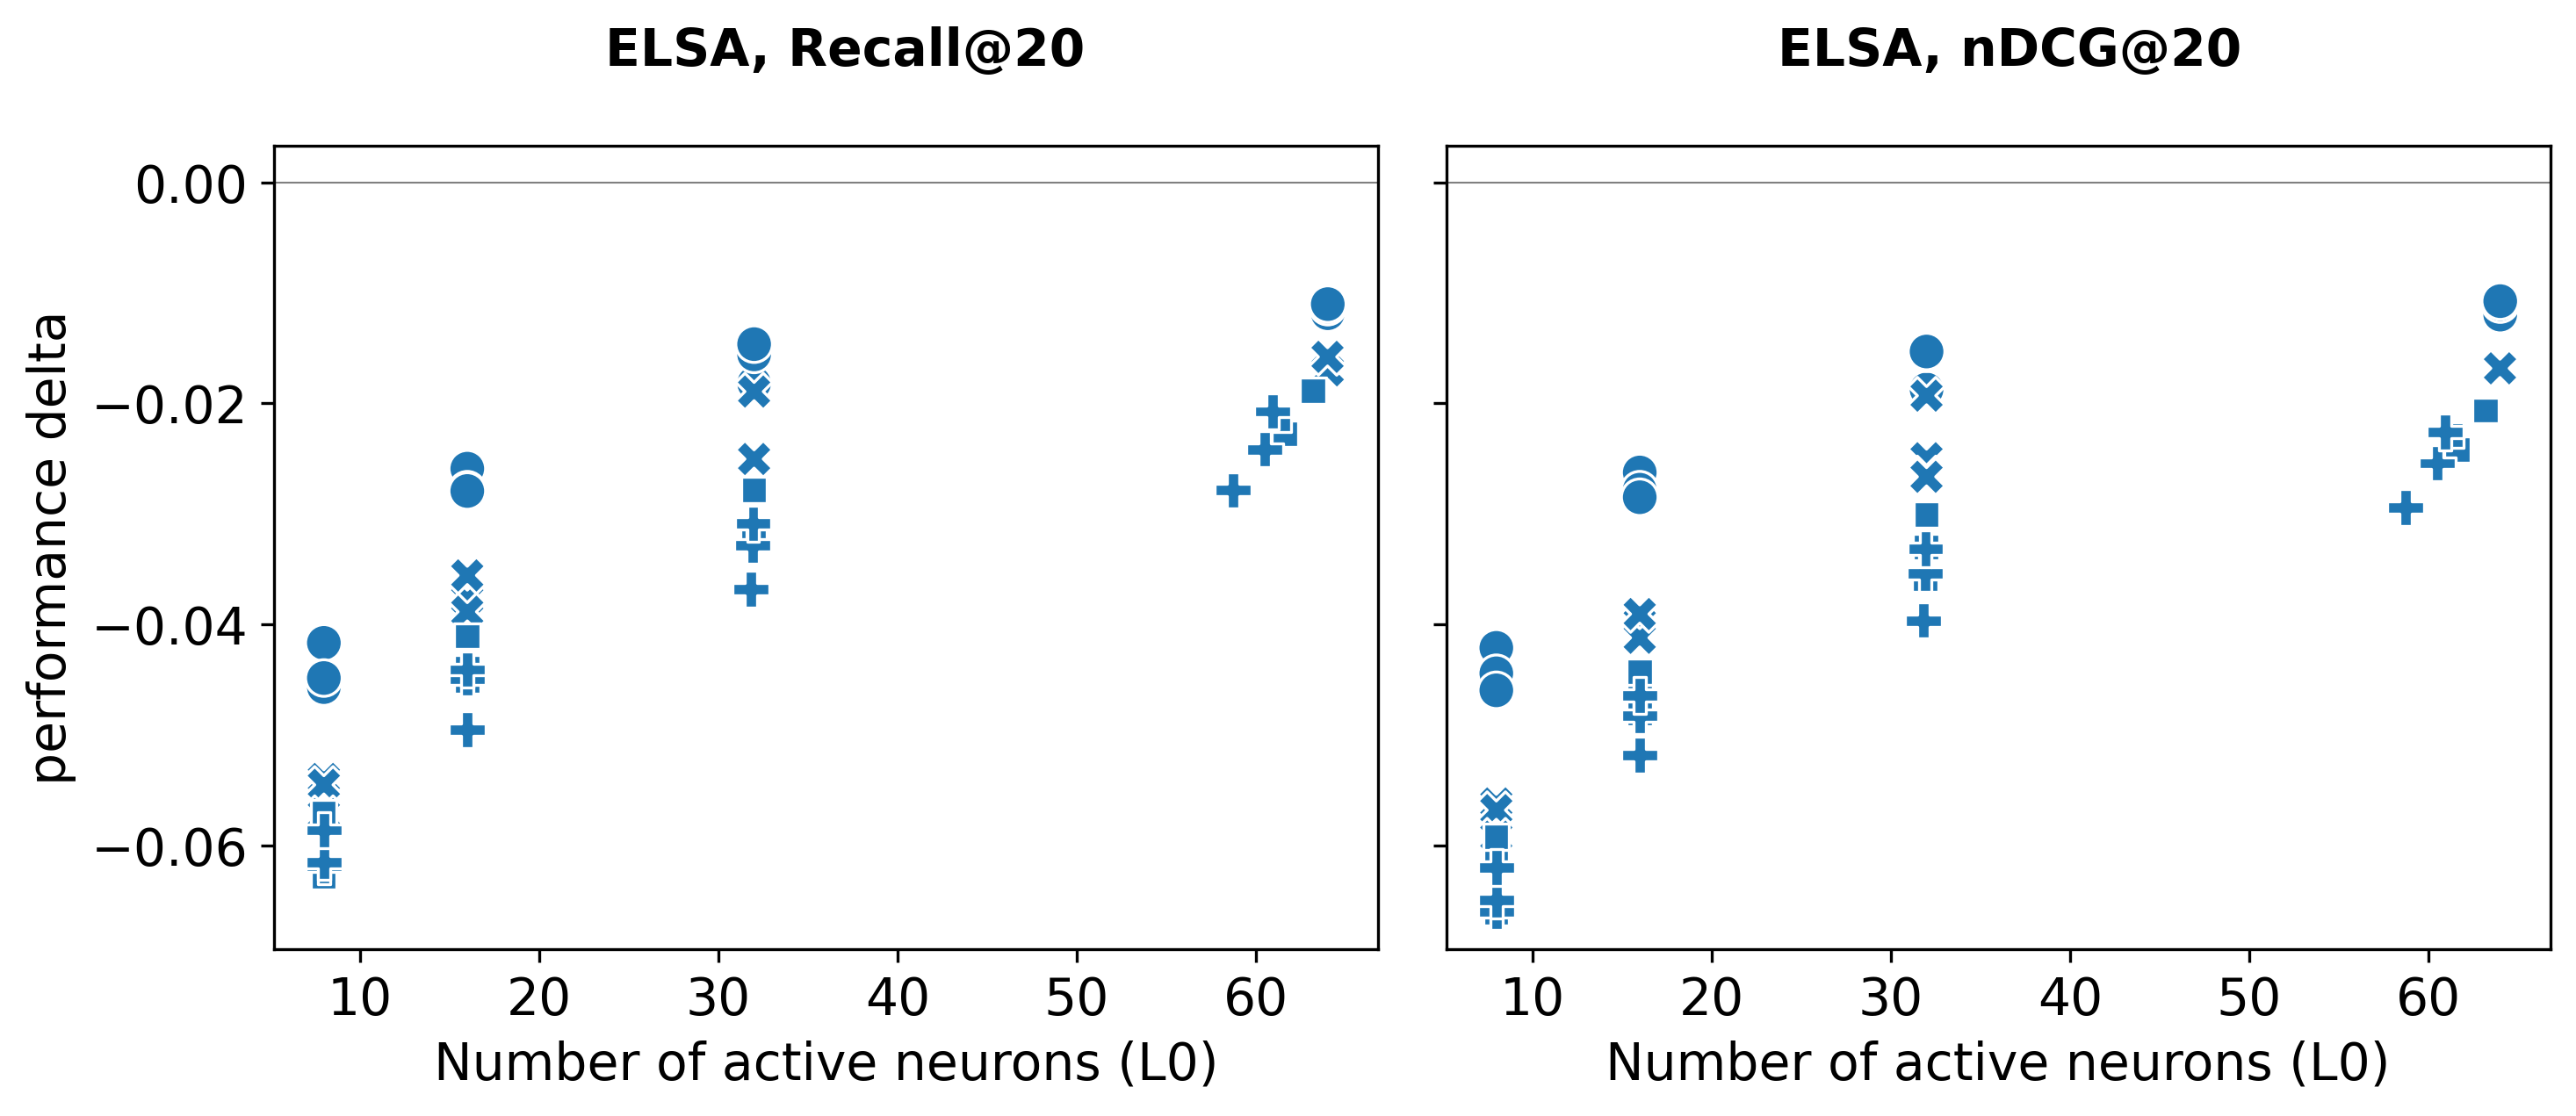

In [5]:
n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), sharey=True, squeeze=False)

for i, dataset in enumerate(DATASETS):
    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join([exp[0], "degradation mean"])
        sns.scatterplot(
            result_dataframes[dataset]["val"]["sae models"]
            .filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))
            .sort(by=["model_class", "cf_model_size"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="cf_model_size",
            ax=ax,
            legend=False,
        )
        ax.axhline(y=0, color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("performance delta")

for j, exp in enumerate(columns):
    axes[0, j].annotate(
        ", ".join([exp[1], f"{'Recall' if exp[0] == 'recall' else 'nDCG'}@20"]), xy=(0.3, 1.1), xycoords="axes fraction", fontsize=14, fontweight="semibold"
    )

plt.tight_layout()

### Relative

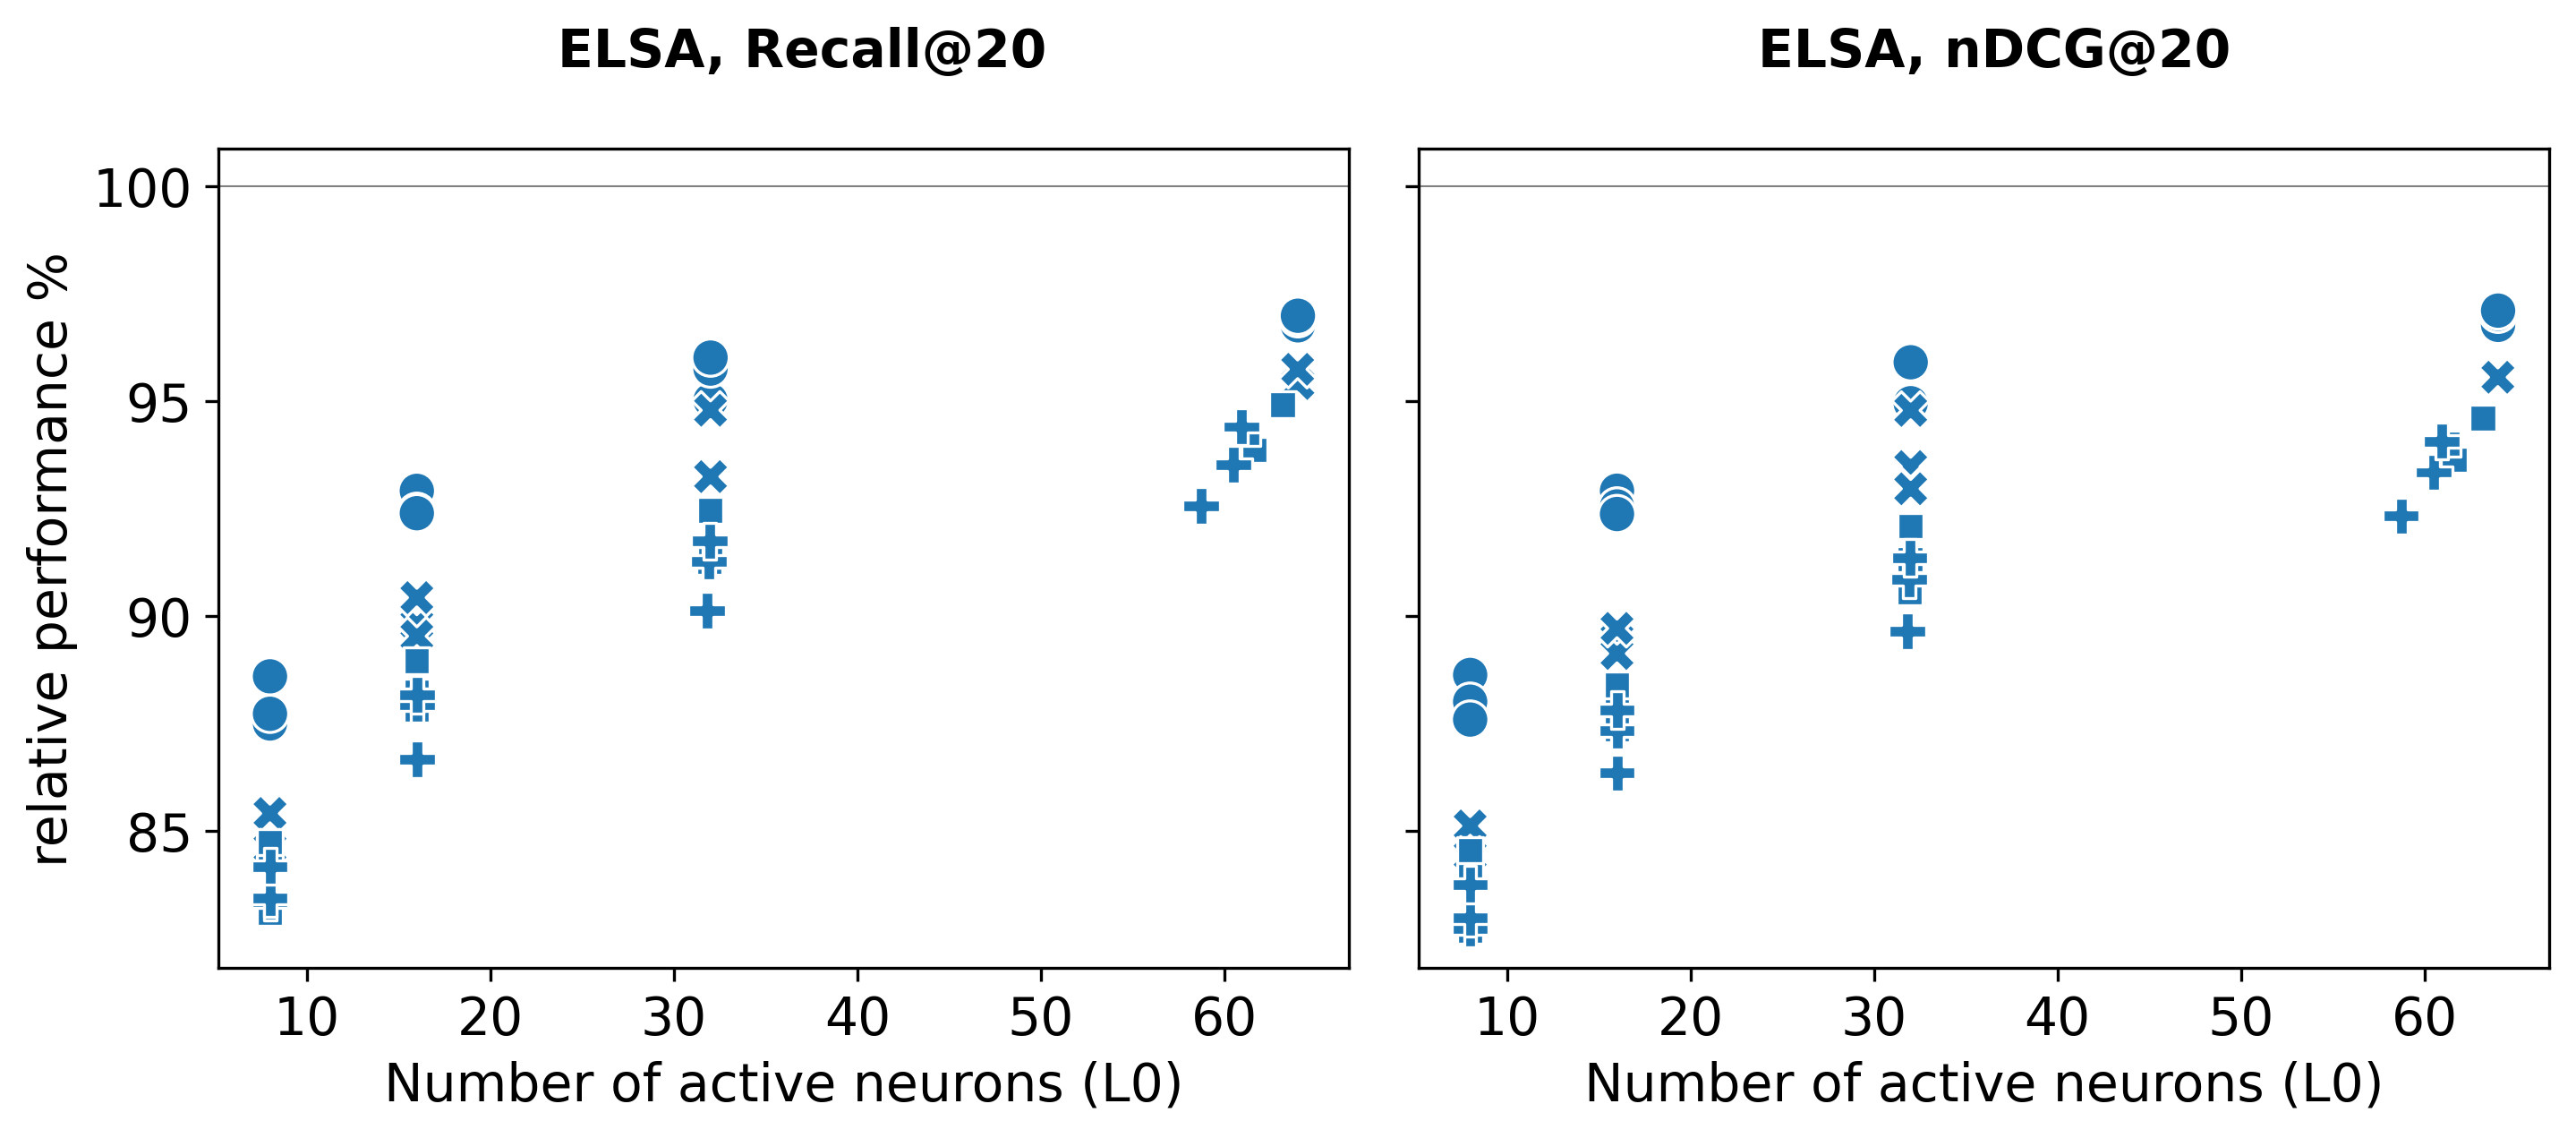

In [6]:
n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), sharey=True, squeeze=False)

for i, dataset in enumerate(DATASETS):
    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join(["relative", exp[0]])
        sns.scatterplot(
            result_dataframes[dataset]["val"]["sae models"]
            .with_columns(
                (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
                (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
            )
            .filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))
            .sort(by=["model_class", "cf_model_size"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="cf_model_size",
            ax=ax,
            legend=False,
        )
        ax.axhline(y=100, color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("relative performance %")

for j, exp in enumerate(columns):
    axes[0, j].annotate(
        ", ".join([exp[1], f"{'Recall' if exp[0] == 'recall' else 'nDCG'}@20"]), xy=(0.3, 1.1), xycoords="axes fraction", fontsize=14, fontweight="semibold"
    )

plt.tight_layout()

## Sparsity vs degradation in downstream accuracy (without sparsity outliers)

### Absolute

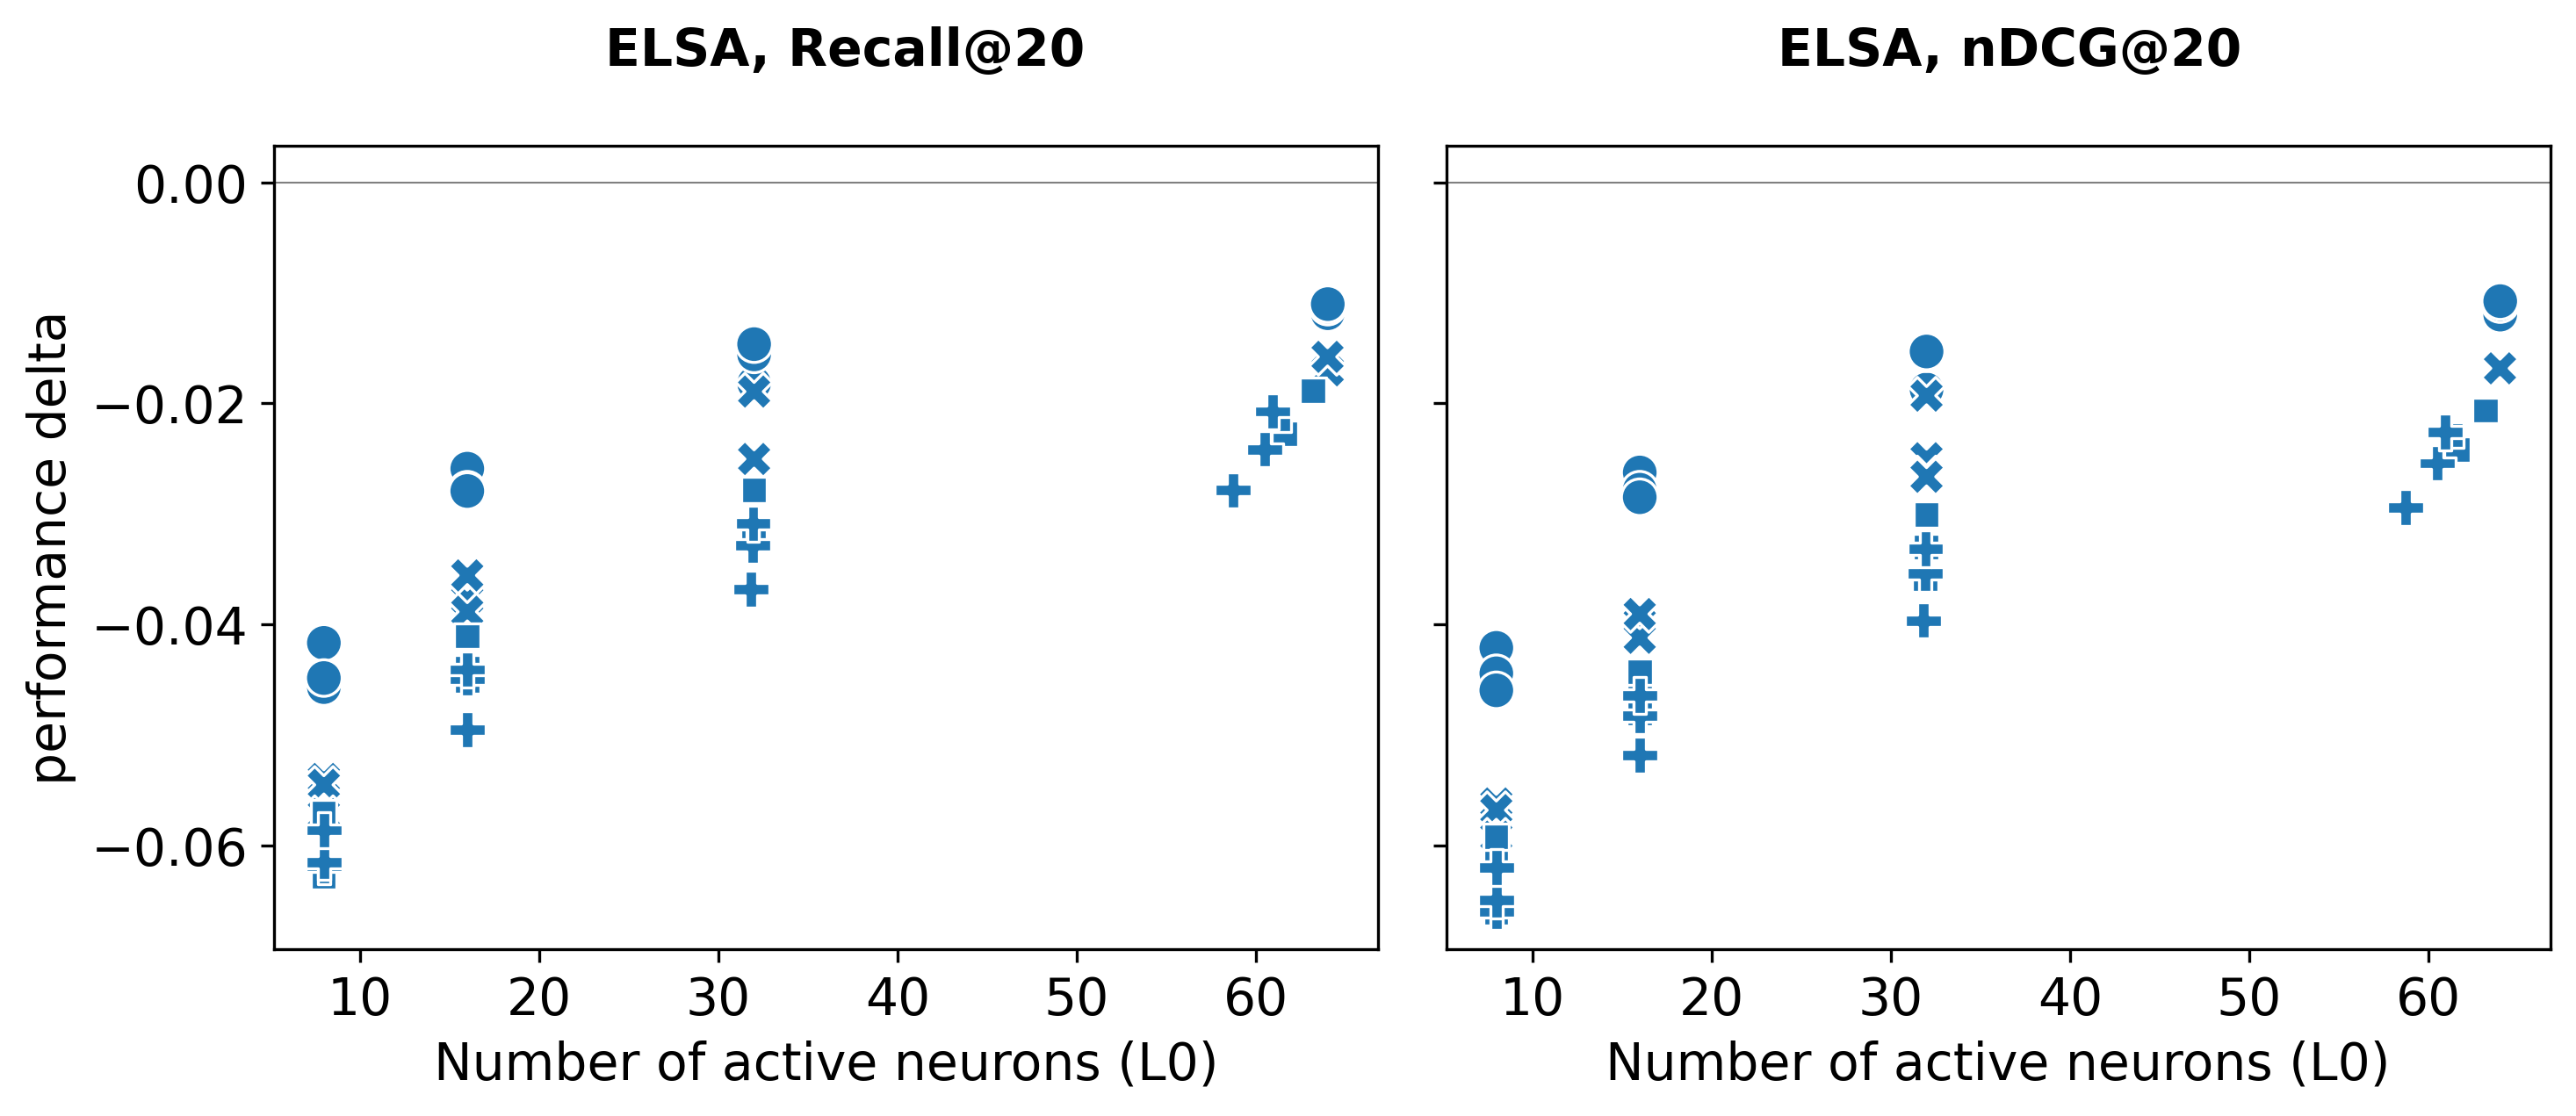

In [7]:
n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), sharex=True, sharey=True, squeeze=False)

for i, dataset in enumerate(DATASETS):
    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join([exp[0], "degradation mean"])
        sns.scatterplot(
            result_dataframes[dataset]["val"]["sae models"]
            .filter((pl.col("l0 mean") >= 2) & (pl.col("l0 mean") <= 128))
            .filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))
            .sort(by=["model_class", "cf_model_size"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="cf_model_size",
            ax=ax,
            legend=False,
        )
        ax.axhline(y=0, color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("performance delta")

for j, exp in enumerate(columns):
    axes[0, j].annotate(
        ", ".join([exp[1], f"{'Recall' if exp[0] == 'recall' else 'nDCG'}@20"]), xy=(0.3, 1.1), xycoords="axes fraction", fontsize=14, fontweight="semibold"
    )

plt.tight_layout()

### Relative performance

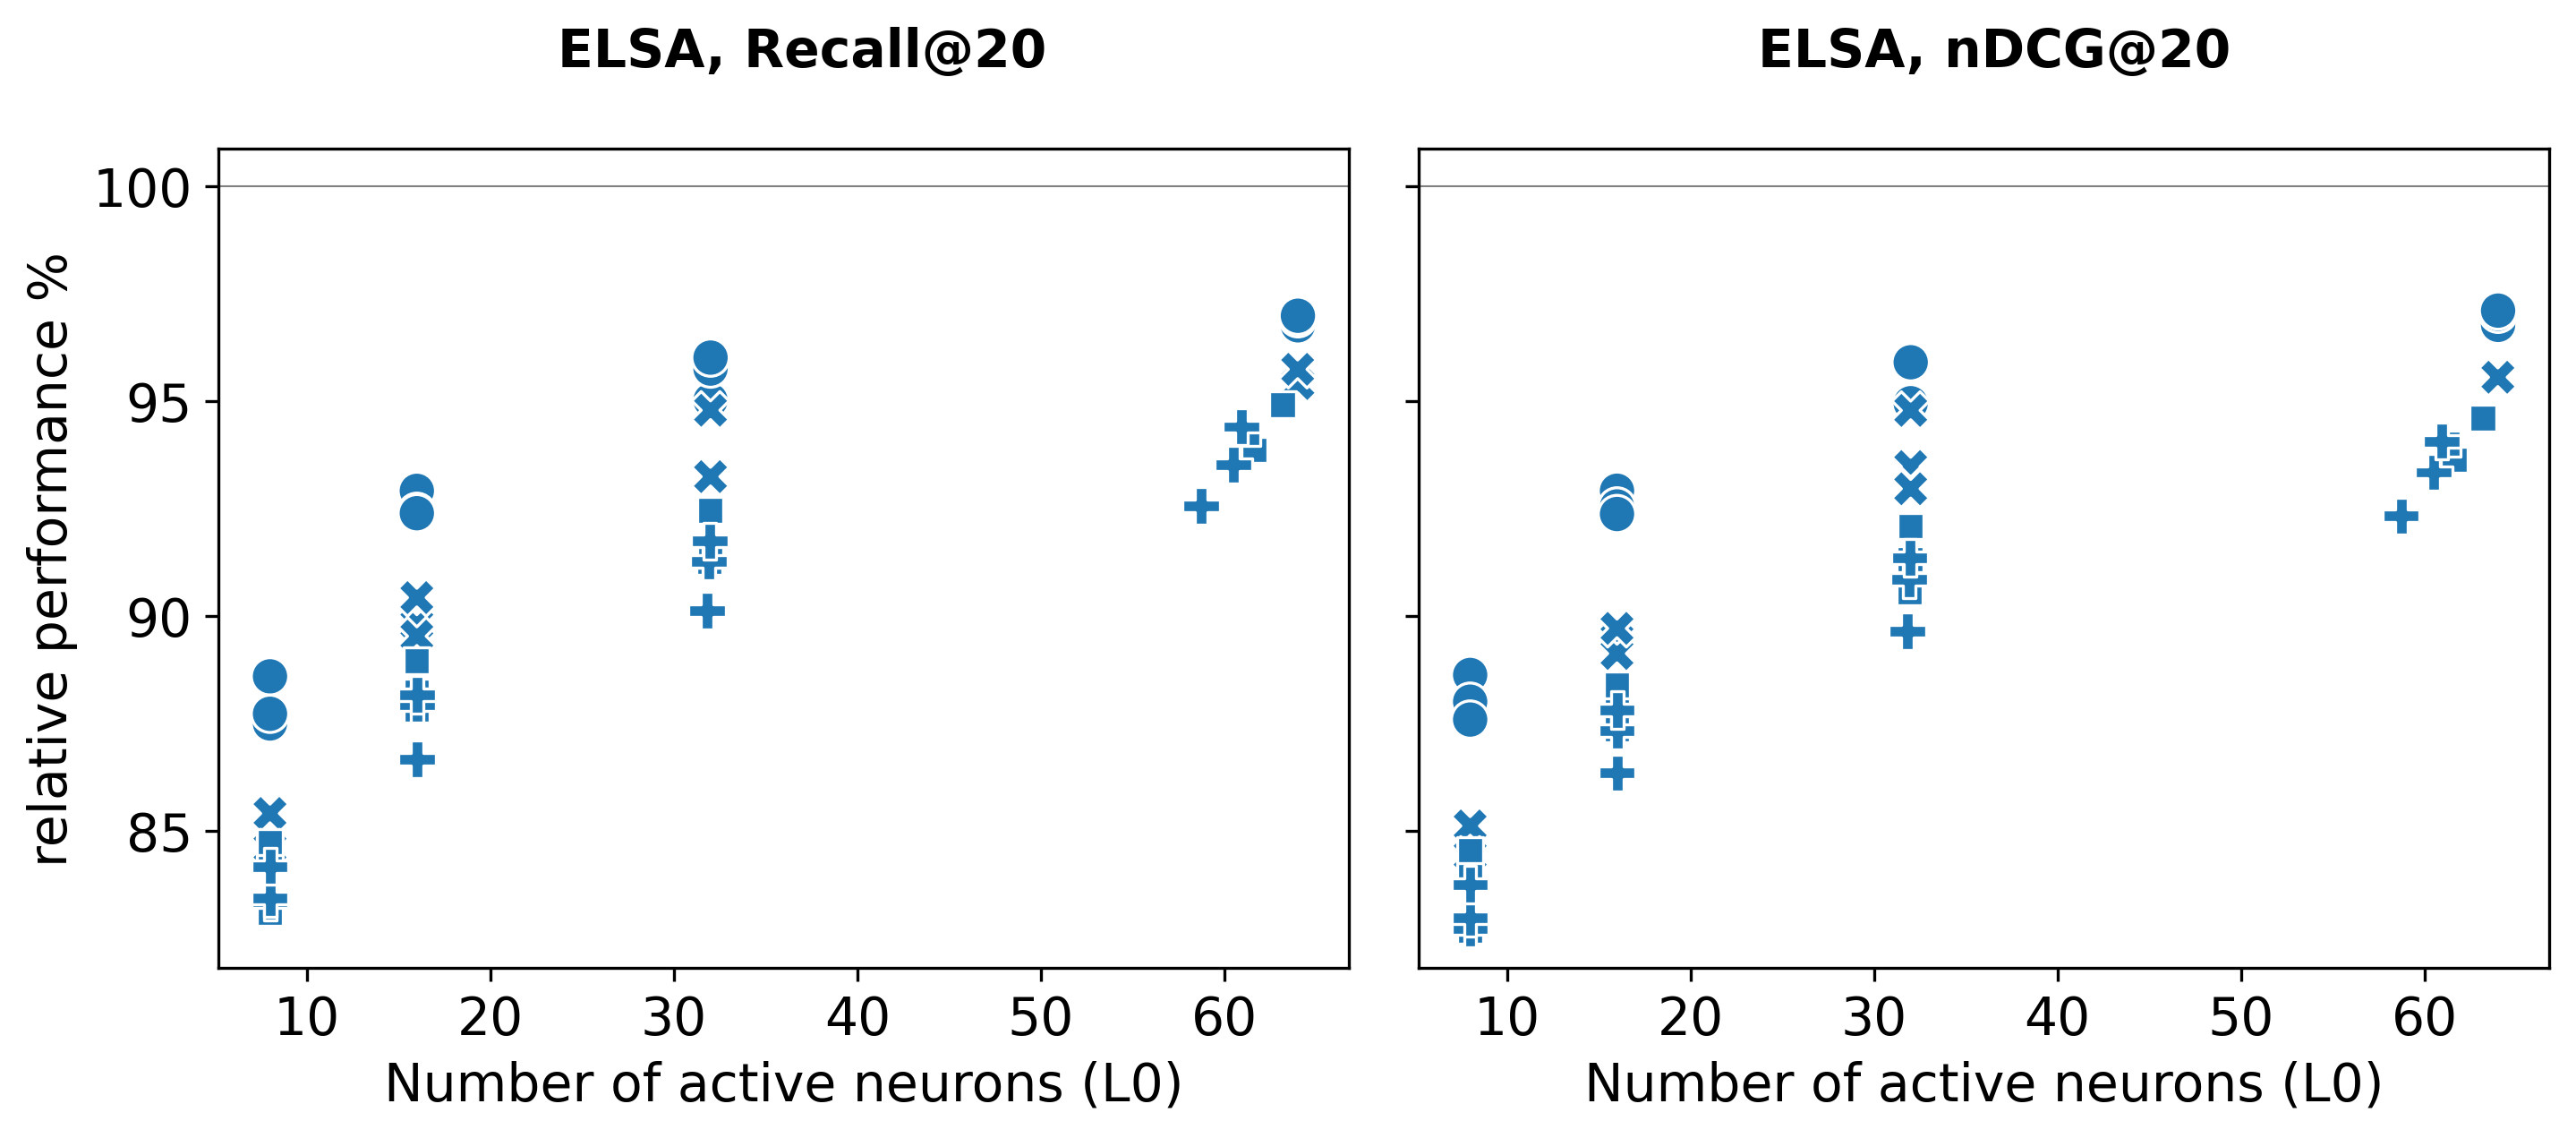

In [8]:
n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), sharex=True, sharey=True, squeeze=False)

for i, dataset in enumerate(DATASETS):
    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join(["relative", exp[0]])
        sns.scatterplot(
            result_dataframes[dataset]["val"]["sae models"]
            .with_columns(
                (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
                (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
            )
            .filter((pl.col("l0 mean") >= 2) & (pl.col("l0 mean") <= 128))
            .filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))
            .sort(by=["model_class", "cf_model_size"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="cf_model_size",
            ax=ax,
            legend=False,
        )
        ax.axhline(y=100, color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("relative performance %")

for j, exp in enumerate(columns):
    axes[0, j].annotate(
        ", ".join([exp[1], f"{'Recall' if exp[0] == 'recall' else 'nDCG'}@20"]), xy=(0.3, 1.1), xycoords="axes fraction", fontsize=14, fontweight="semibold"
    )

plt.tight_layout()

## Best checkpoint selection

In [9]:
def get_best_checkpoints_per_cf_model_size(dataset: str) -> pl.Series:
    return (
        result_dataframes[dataset]["val"]["sae models"]
        .with_columns(
            (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
            (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
        )
        .with_columns(pl.col("pretrained_model_checkpoint").str.replace(r"-.*", "").alias("cf_model"))
        .with_columns(
            pl.when(pl.col("l0 mean") <= 10)
            .then(10)
            .otherwise((pl.when(pl.col("l0 mean") <= 25)).then(25).otherwise(pl.when(pl.col("l0 mean") <= 50).then(50).otherwise(100)))
            .alias("sparsity bucket")
        )
        .sort("relative ndcg", descending=True)
        .group_by("cf_model", "model_class", "cf_model_size", "sparsity bucket")
        .first()["checkpoint"]
    )

# Test results

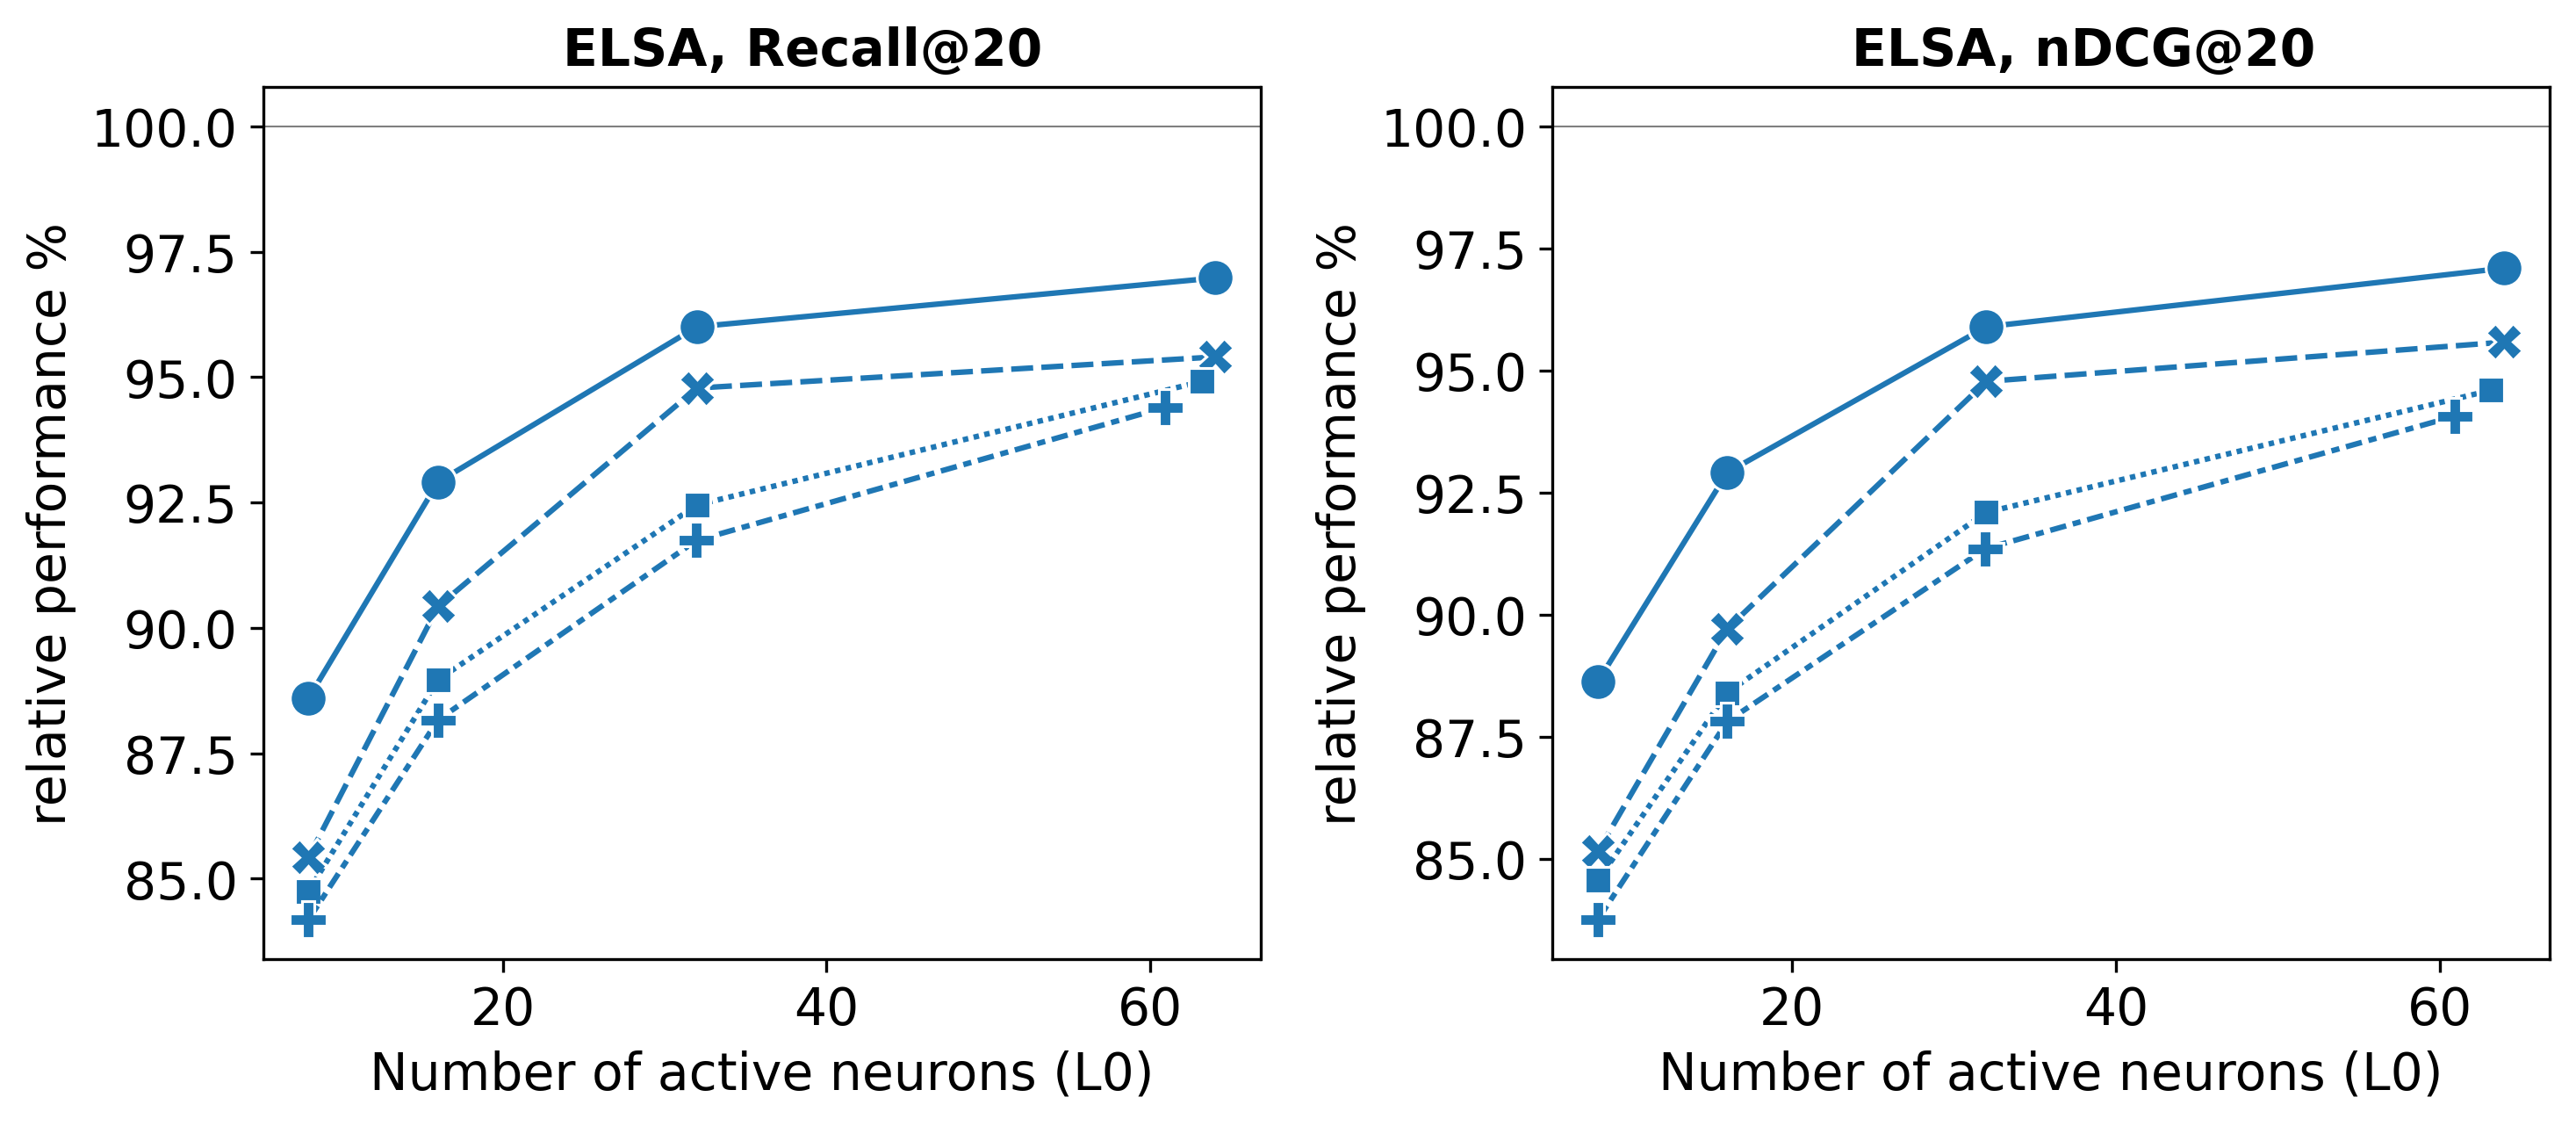

In [10]:
n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), squeeze=False)

for i, dataset in enumerate(DATASETS):
    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join(["relative", exp[0]])
        sns.lineplot(
            result_dataframes[dataset]["test"]["sae models"]
            .with_columns(
                (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
                (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
            )
            .filter(pl.col("checkpoint").is_in(get_best_checkpoints_per_cf_model_size(dataset).to_list()))
            .filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))
            .sort(by=["model_class", "cf_model_size"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="cf_model_size",
            ax=ax,
            legend=False,
            markers=True,
        )
        ax.axhline(y=100, color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("relative performance %")

for j, exp in enumerate(columns):
    axes[0, j].annotate(
        ", ".join([exp[1], f"{'Recall' if exp[0] == 'recall' else 'nDCG'}@20"]), xy=(0.3, 1.025), xycoords="axes fraction", fontsize=14, fontweight="semibold"
    )

plt.tight_layout()

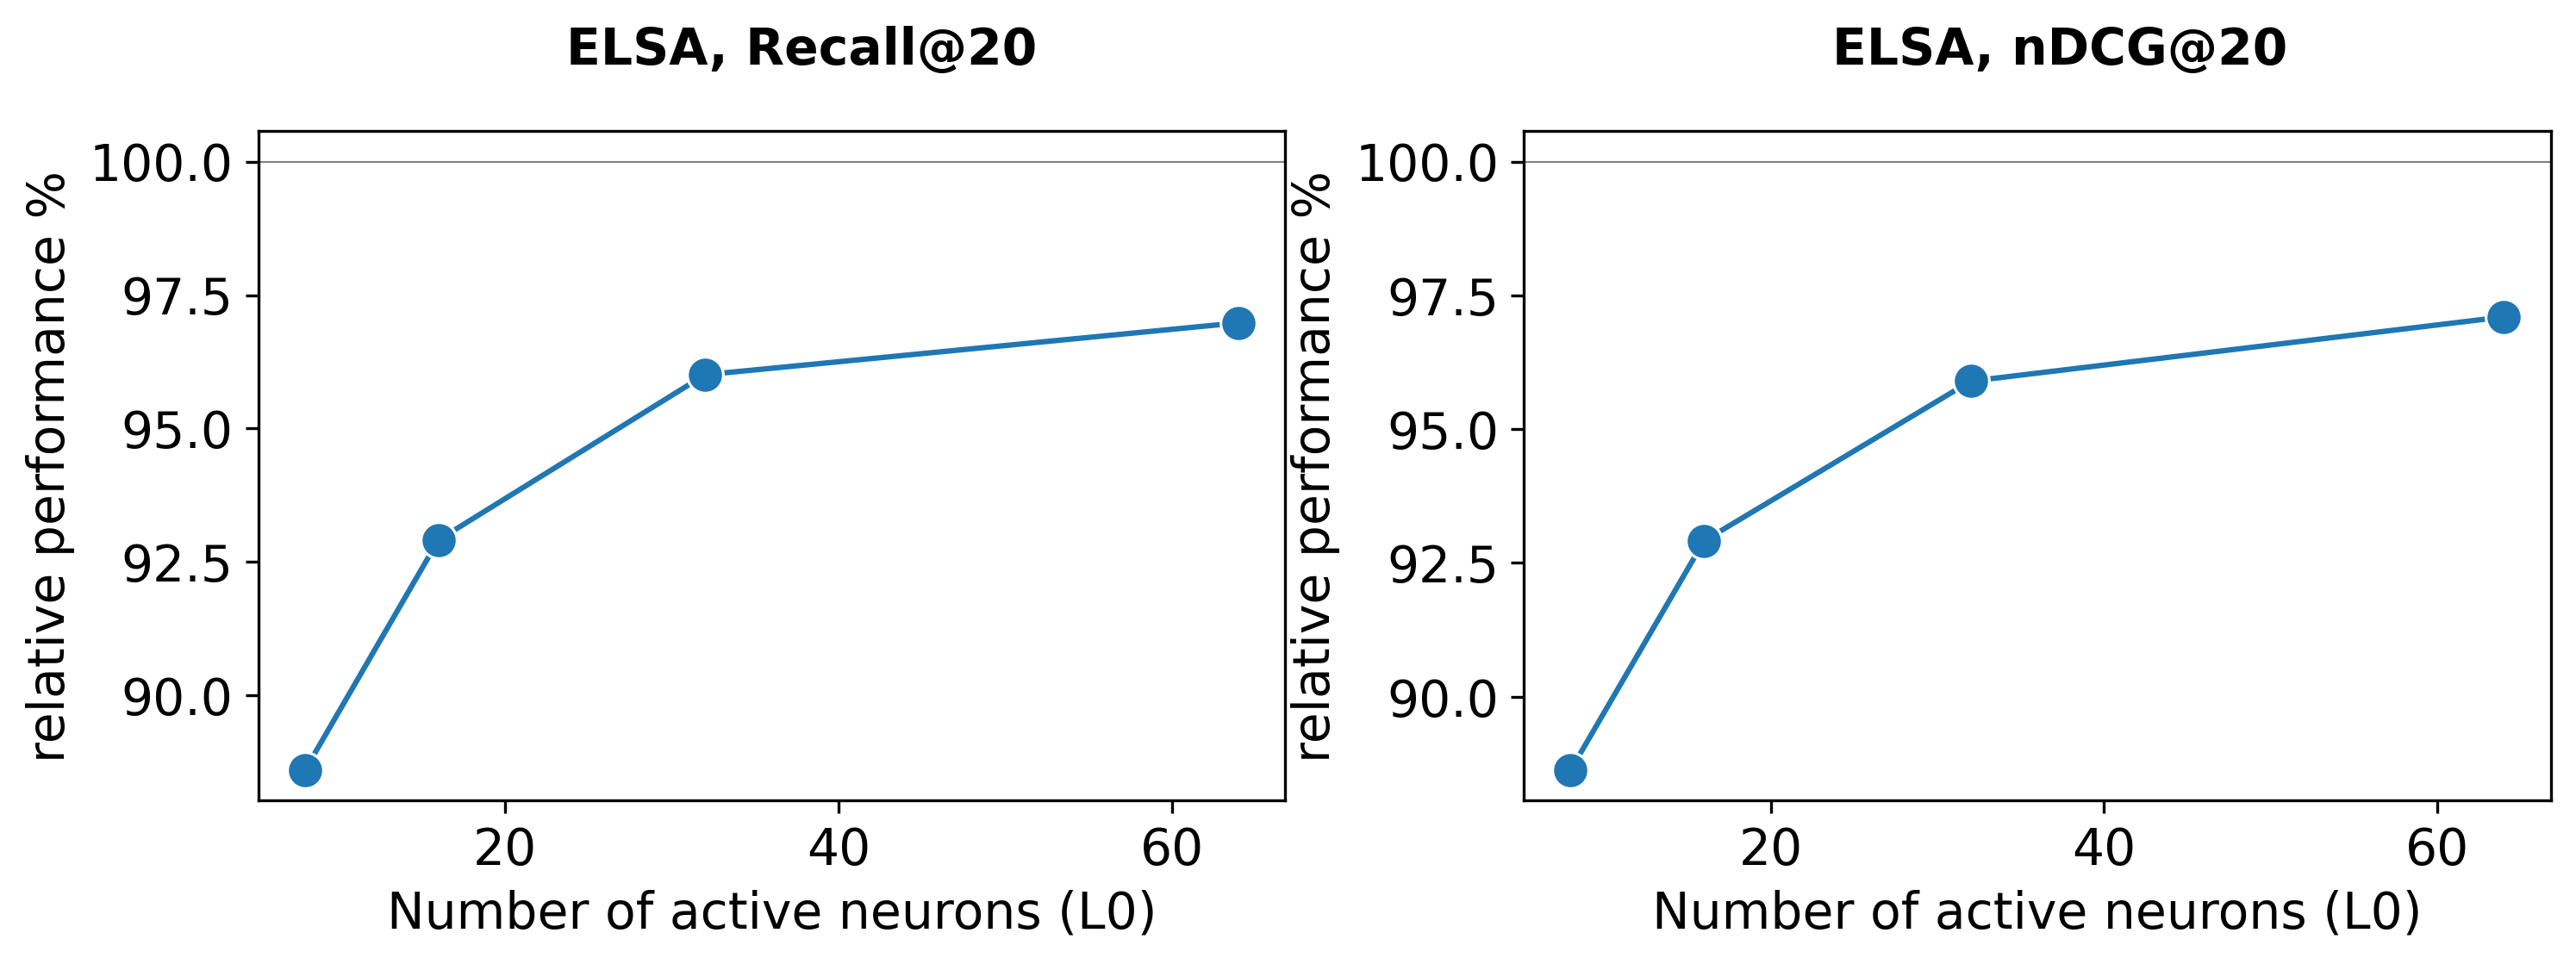

In [11]:
cf_model_size = 1  # requested CF size bucket

n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for i, dataset in enumerate(DATASETS):
    base_df = (
        result_dataframes[dataset]["test"]["sae models"]
        .with_columns(
            (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
            (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
        )
        .filter(pl.col("checkpoint").is_in(get_best_checkpoints_per_cf_model_size(dataset).to_list()))
        .filter(pl.col("cf_model_size") == cf_model_size)
    )

    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join(["relative", exp[0]])
        plot_df = base_df.filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))

        if plot_df.height == 0:
            ax.text(0.5, 0.5, f"No rows for cf_model_size={cf_model_size}", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        sns.lineplot(
            plot_df.sort(by=["model_class"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="model_class",
            ax=ax,
            legend=False,
            markers=True,
        )
        ax.axhline(y=100, color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("relative performance %")

for j, exp in enumerate(columns):
    axes[0, j].annotate(
        ", ".join([exp[1], f"{'Recall' if exp[0] == 'recall' else 'nDCG'}@20"]), xy=(0.3, 1.1), xycoords="axes fraction", fontsize=14, fontweight="semibold"
    )

plt.tight_layout()

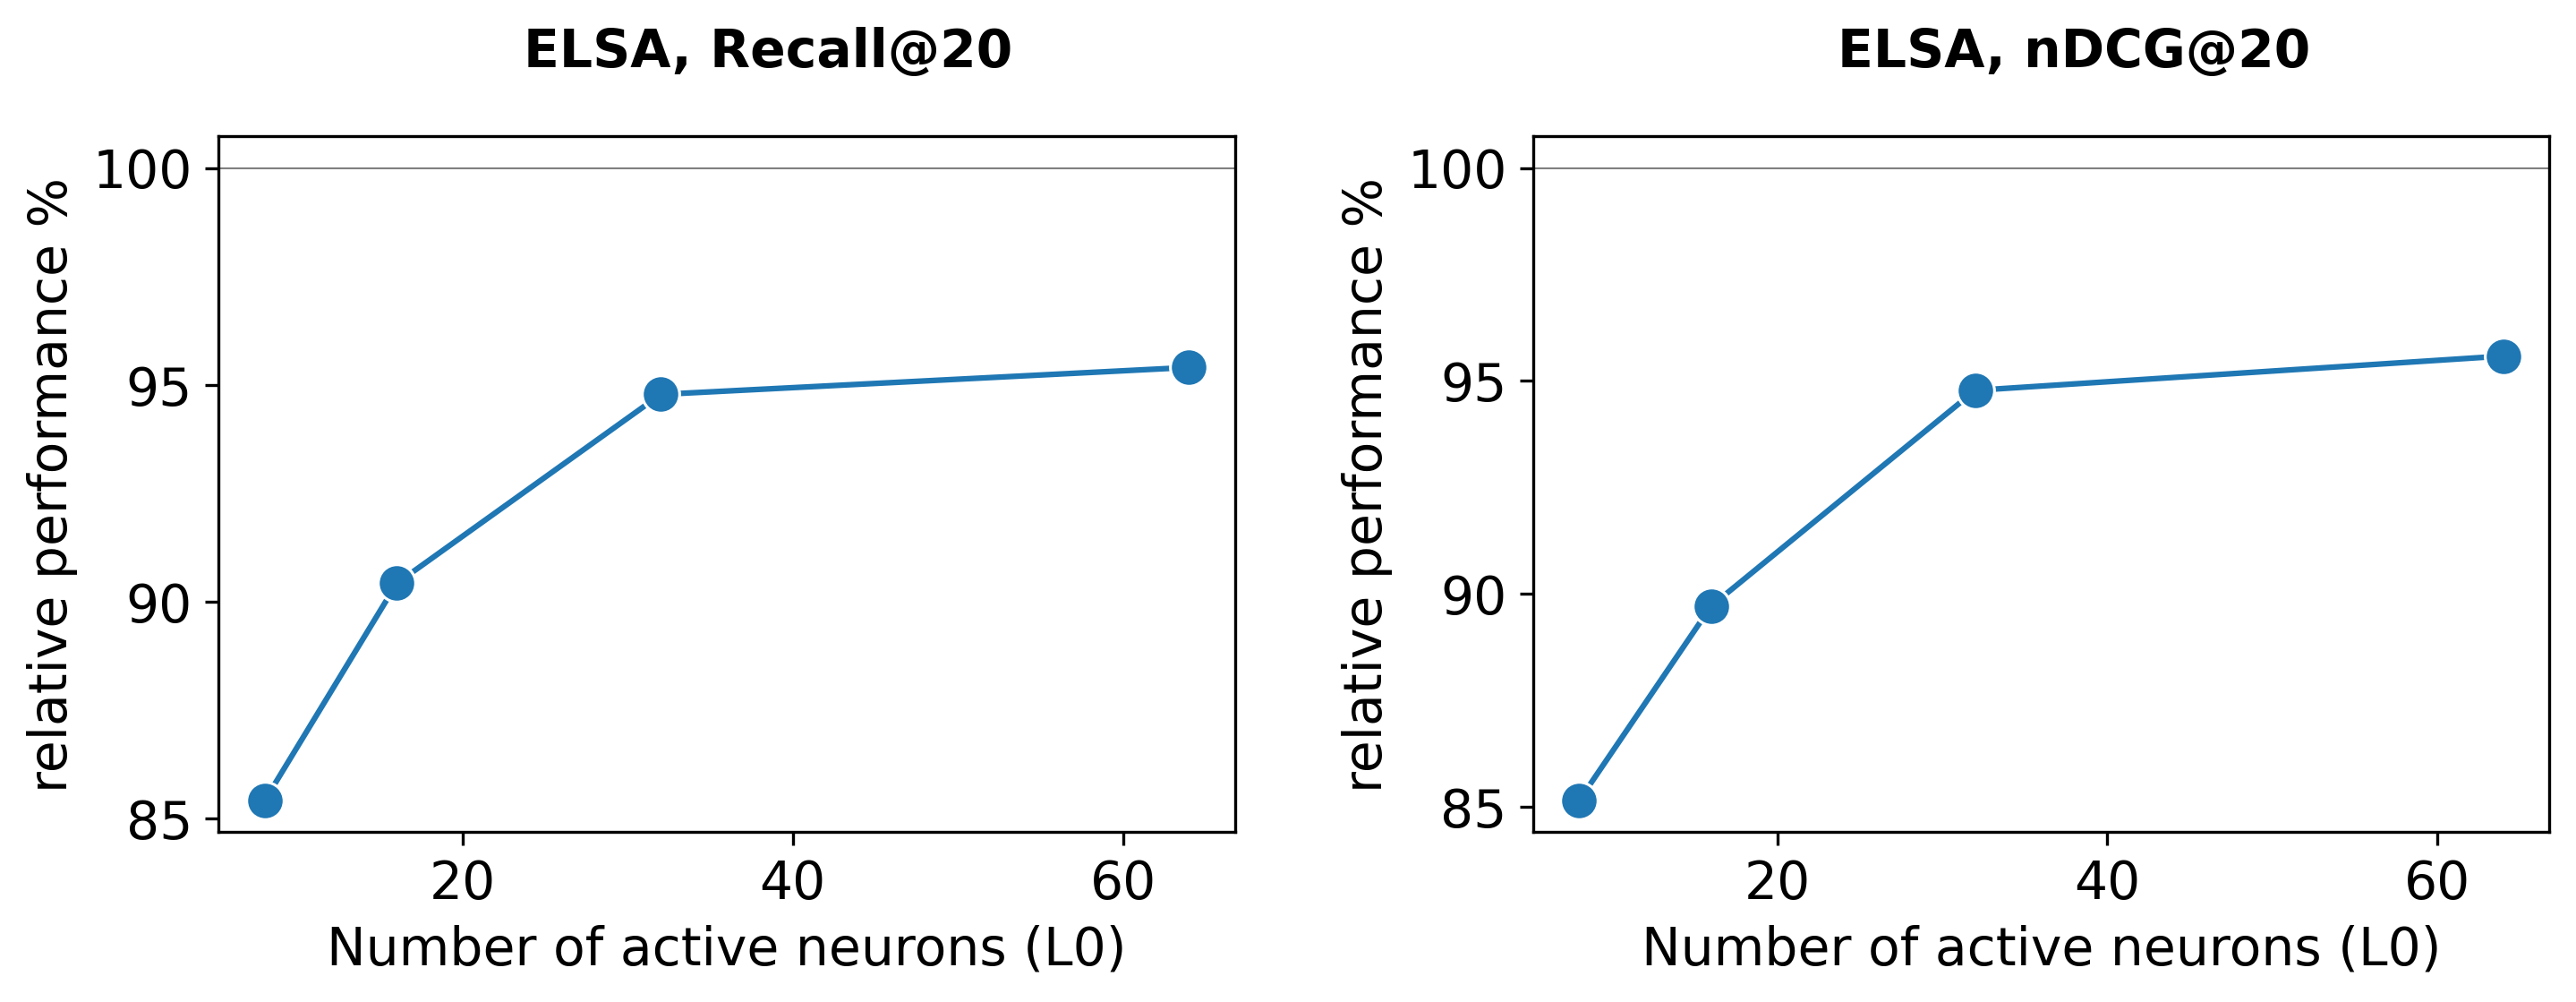

In [12]:
cf_model_size = 2  # requested CF size bucket

n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for i, dataset in enumerate(DATASETS):
    base_df = (
        result_dataframes[dataset]["test"]["sae models"]
        .with_columns(
            (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
            (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
        )
        .filter(pl.col("checkpoint").is_in(get_best_checkpoints_per_cf_model_size(dataset).to_list()))
        .filter(pl.col("cf_model_size") == cf_model_size)
    )

    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join(["relative", exp[0]])
        plot_df = base_df.filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))

        if plot_df.height == 0:
            ax.text(0.5, 0.5, f"No rows for cf_model_size={cf_model_size}", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        sns.lineplot(
            plot_df.sort(by=["model_class"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="model_class",
            ax=ax,
            legend=False,
            markers=True,
        )
        ax.axhline(y=100, color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("relative performance %")

for j, exp in enumerate(columns):
    axes[0, j].annotate(
        ", ".join([exp[1], f"{'Recall' if exp[0] == 'recall' else 'nDCG'}@20"]), xy=(0.3, 1.1), xycoords="axes fraction", fontsize=14, fontweight="semibold"
    )

plt.tight_layout()

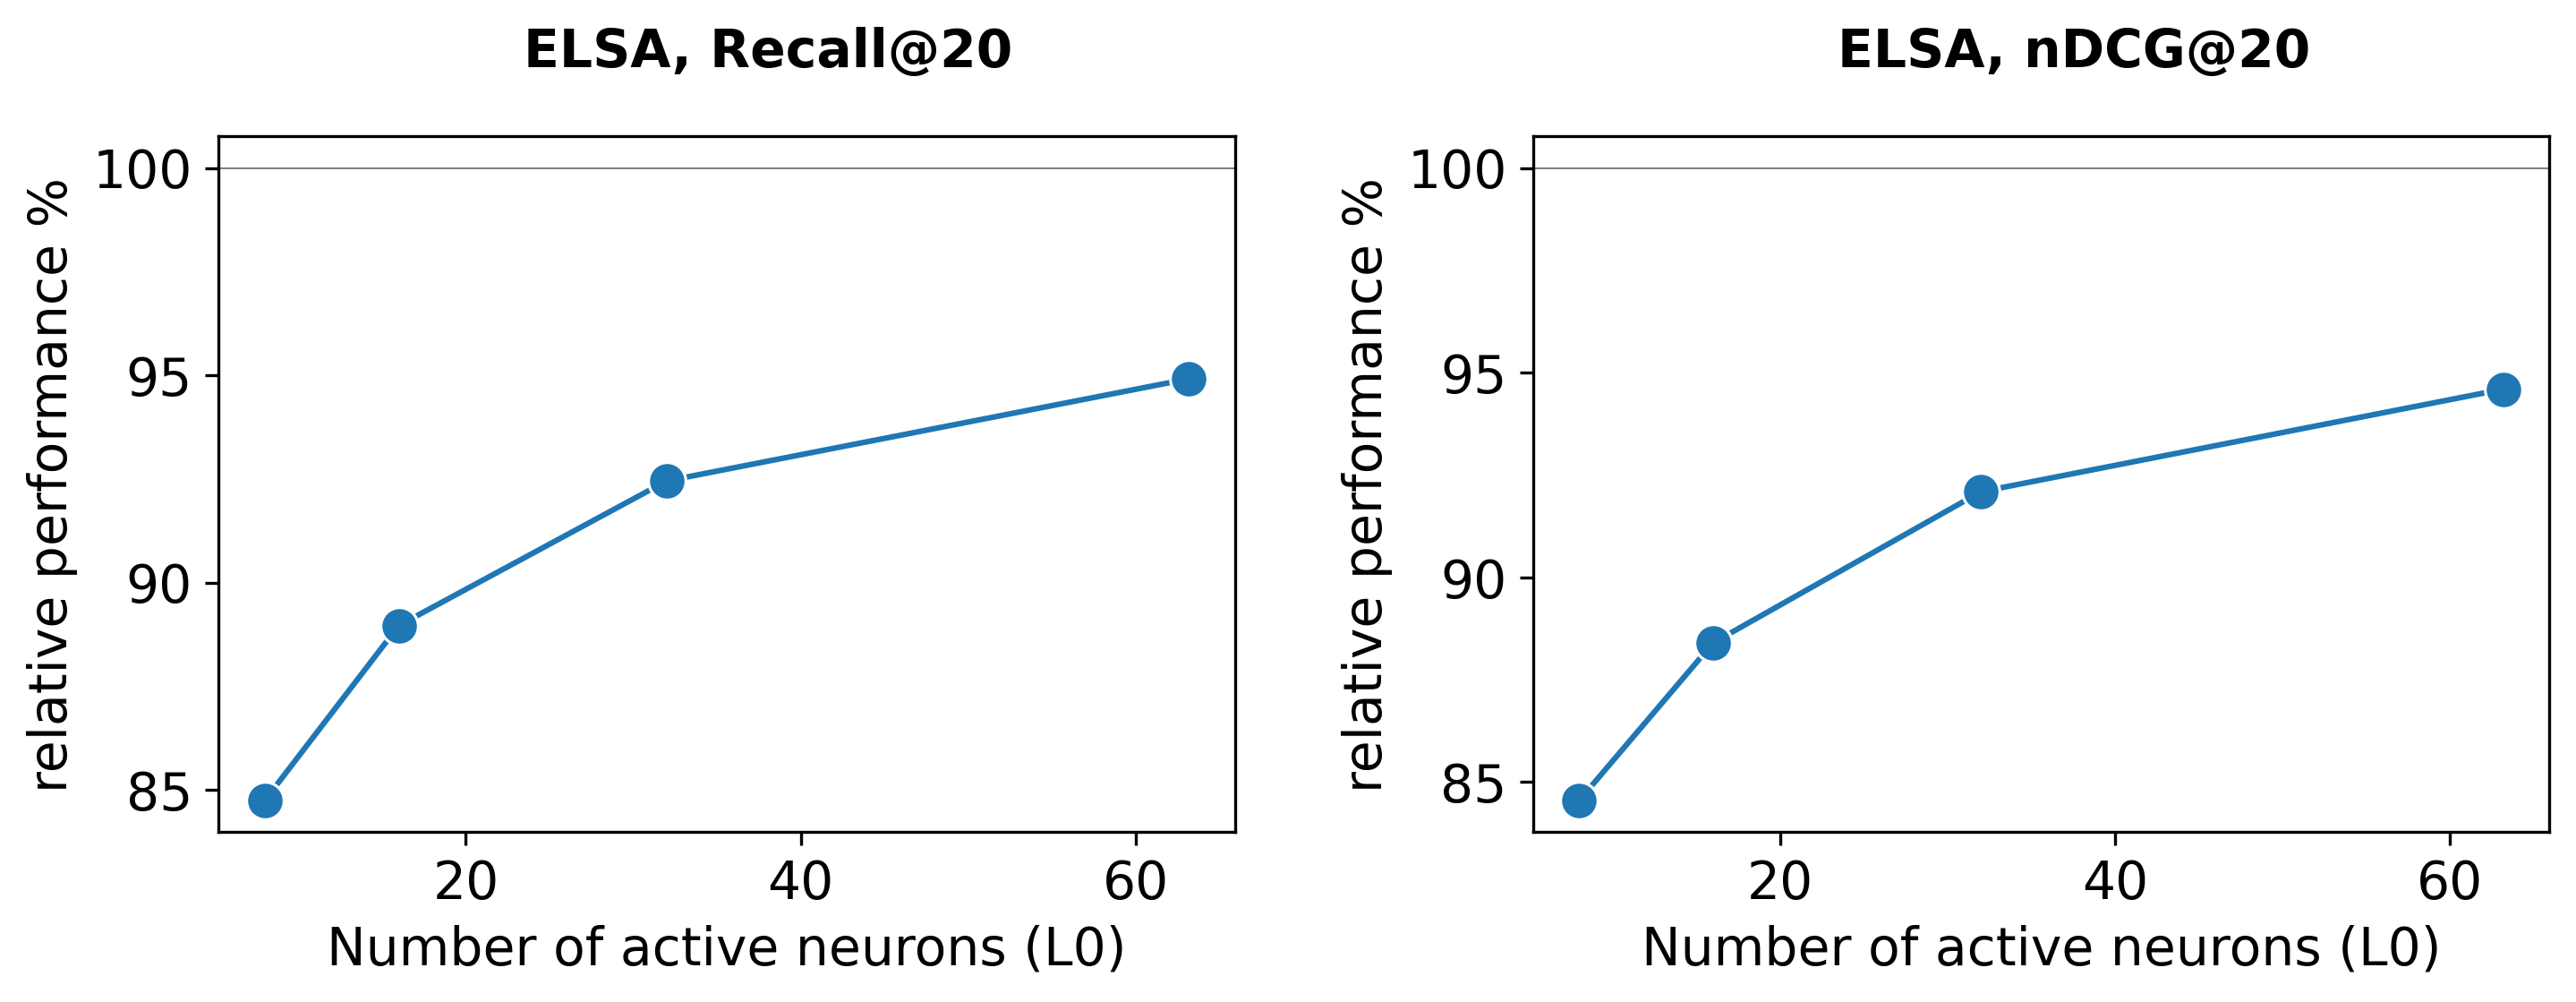

In [13]:
cf_model_size = 4  # requested CF size bucket

n_rows = len(DATASETS)
columns = [("recall", "ELSA"), ("ndcg", "ELSA")]
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

for i, dataset in enumerate(DATASETS):
    base_df = (
        result_dataframes[dataset]["test"]["sae models"]
        .with_columns(
            (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
            (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
        )
        .filter(pl.col("checkpoint").is_in(get_best_checkpoints_per_cf_model_size(dataset).to_list()))
        .filter(pl.col("cf_model_size") == cf_model_size)
    )

    for j, exp in enumerate(columns):
        ax = axes[i, j]
        y = " ".join(["relative", exp[0]])
        plot_df = base_df.filter(pl.col("pretrained_model_checkpoint").str.starts_with(exp[1]))

        if plot_df.height == 0:
            ax.text(0.5, 0.5, f"No rows for cf_model_size={cf_model_size}", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        sns.lineplot(
            plot_df.sort(by=["model_class"]),
            x="l0 mean",
            y=y,
            hue="model_class",
            style="model_class",
            ax=ax,
            legend=False,
            markers=True,
        )
        ax.axhline(y=100, color="grey", linewidth=0.5)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel("relative performance %")

for j, exp in enumerate(columns):
    axes[0, j].annotate(
        ", ".join([exp[1], f"{'Recall' if exp[0] == 'recall' else 'nDCG'}@20"]), xy=(0.3, 1.1), xycoords="axes fraction", fontsize=14, fontweight="semibold"
    )

plt.tight_layout()

In [14]:
result_dataframes[DATASETS[0]]["val"]["sae models"].filter((pl.col("k") == 16) & (pl.col("embedding_dim") == 8192) & (pl.col("scaling_factor") == 8))

checkpoint,dataset,pretrained_model_checkpoint,model_module,model_class,embedding_dim,reconstruction_loss,l1_coef,k,epochs,early_stopping,batch_size,lr,beta1,beta2,seed,cosine mean,cosine se,l0 mean,l0 se,dead neurons,recall mean,recall se,recall degradation mean,recall degradation se,ndcg mean,ndcg se,ndcg degradation mean,ndcg degradation se,input_dim,scaling_factor,cf_model,cf_model_size
str,str,str,str,str,i64,str,f64,i64,i64,i64,i64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i32,str,i32
"""TopKSAE-8192-aee72a99.json""","""ml-32m-filtered""","""ELSA-1024-7f035e3d.ckpt""","""sae""","""TopKSAE (Cosine)""",8192,"""Cosine""",0.0003,16,250,50,1024,0.0003,0.9,0.99,42,0.778228,0.001603,16.0,0.0,379,0.335923,0.00247,-0.035558,0.001285,0.340528,0.002536,-0.03905,0.001116,1024,8,"""ELSA""",2


In [15]:
result_dataframes[DATASETS[0]]["val"]["sae models"].filter((pl.col("k") == 16) & (pl.col("embedding_dim") == 4096) & (pl.col("scaling_factor") == 4))

checkpoint,dataset,pretrained_model_checkpoint,model_module,model_class,embedding_dim,reconstruction_loss,l1_coef,k,epochs,early_stopping,batch_size,lr,beta1,beta2,seed,cosine mean,cosine se,l0 mean,l0 se,dead neurons,recall mean,recall se,recall degradation mean,recall degradation se,ndcg mean,ndcg se,ndcg degradation mean,ndcg degradation se,input_dim,scaling_factor,cf_model,cf_model_size
str,str,str,str,str,i64,str,f64,i64,i64,i64,i64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i32,str,i32
"""TopKSAE-4096-ef04bab3.json""","""ml-32m-filtered""","""ELSA-1024-7f035e3d.ckpt""","""sae""","""TopKSAE (Cosine)""",4096,"""Cosine""",0.0003,16,250,50,1024,0.0003,0.9,0.99,42,0.776061,0.001673,16.0,0.0,114,0.332232,0.002489,-0.038848,0.00131,0.337745,0.002538,-0.041201,0.001129,1024,4,"""ELSA""",2


In [16]:
dataset = DATASETS[0]
# Leave as None to auto-pick the largest available input_dim in the next cell.
input_dim = None

In [17]:
result_dataframes[dataset]["test"]["sae models"].select(
    ["embedding_dim", "k", "cf_model_size", "checkpoint"]
).sort(["embedding_dim", "k"])

embedding_dim,k,cf_model_size,checkpoint
i64,i64,i32,str
1024,8,1,"""TopKSAE-1024-b7aad94c.json"""
1024,16,1,"""TopKSAE-1024-f0b0da0a.json"""
1024,32,1,"""TopKSAE-1024-4d51a427.json"""
1024,64,1,"""TopKSAE-1024-77965725.json"""
2048,8,1,"""TopKSAE-2048-1148cc05.json"""
…,…,…,…
16384,64,4,"""TopKSAE-16384-a4f931b4.json"""
32768,8,8,"""TopKSAE-32768-27b85212.json"""
32768,16,8,"""TopKSAE-32768-cf3da8cf.json"""


# Effect of SAE scaling factor

In [18]:
dataset = DATASETS[0]
split = "val"

sae_table = result_dataframes[dataset][split]["sae models"]
available_input_dims = sorted(sae_table.select("input_dim").unique().to_series().to_list())
if not available_input_dims:
    raise ValueError(f"No SAE rows found for dataset={dataset}, split={split}.")

# Use explicit input_dim if already set; otherwise pick the largest available one.
if "input_dim" not in globals() or input_dim is None:
    input_dim = int(available_input_dims[-1])
elif input_dim not in available_input_dims:
    raise ValueError(f"input_dim={input_dim} is not available. Choose one of: {available_input_dims}")

_df = (
    sae_table
    .filter(pl.col("input_dim") == input_dim)
    .with_columns(
        [
            (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
            (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
        ]
    )
    .sort(by=["model_class", "cf_model"])
)

print(f"Using input_dim={input_dim}. Available input_dims={available_input_dims}")
print(f"Rows in _df: {_df.height}")

Using input_dim=4096. Available input_dims=[512, 1024, 2048, 4096]
Rows in _df: 12


## Active neurons per input

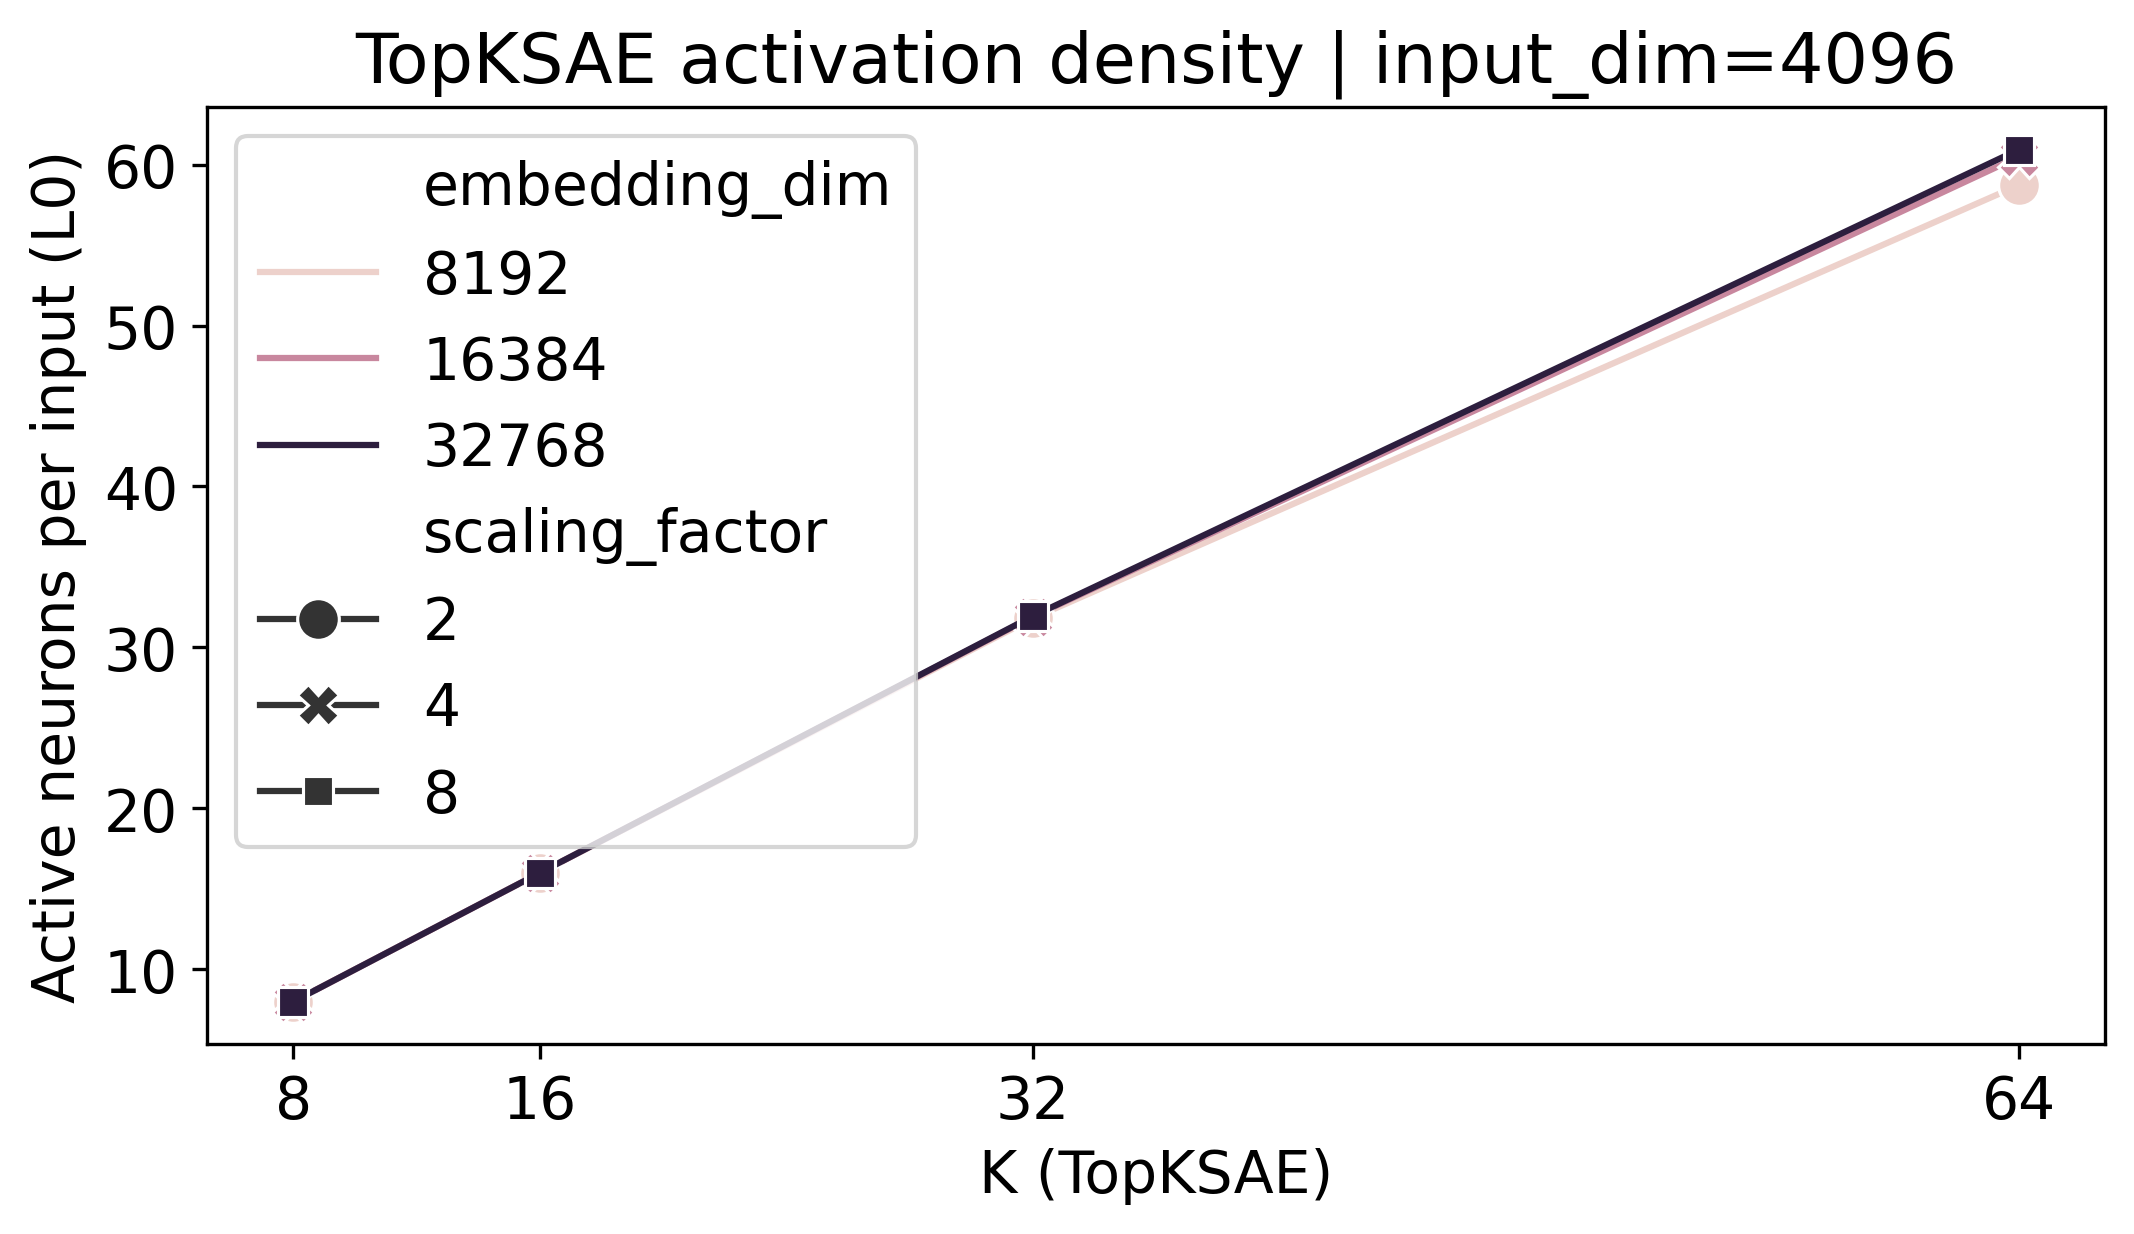

In [19]:
metric = "l0 mean"
plot_df = _df.filter(pl.col("cf_model") == "ELSA").filter(pl.col("model_class").str.starts_with("TopKSAE"))

fig, ax = plt.subplots(1, 1, figsize=(7, 4), constrained_layout=True)
sns.lineplot(
    data=plot_df,
    x="k",
    y=metric,
    hue="embedding_dim",
    style="scaling_factor",
    markers=True,
    dashes=False,
    estimator="mean",
    errorbar=("ci", 95),
    ax=ax,
)
ax.set_xticks(sorted(plot_df.select("k").unique().to_series().to_list()))
ax.set_xlabel("K (TopKSAE)")
ax.set_ylabel("Active neurons per input (L0)")
ax.set_title(f"TopKSAE activation density | input_dim={input_dim}")

plt.savefig(FIGURES_DIR / f"{dataset}_{split}_dim{input_dim}_{metric.replace(' ', '-')}_topksae.png", bbox_inches="tight")
plt.show()

## Cosine similarity

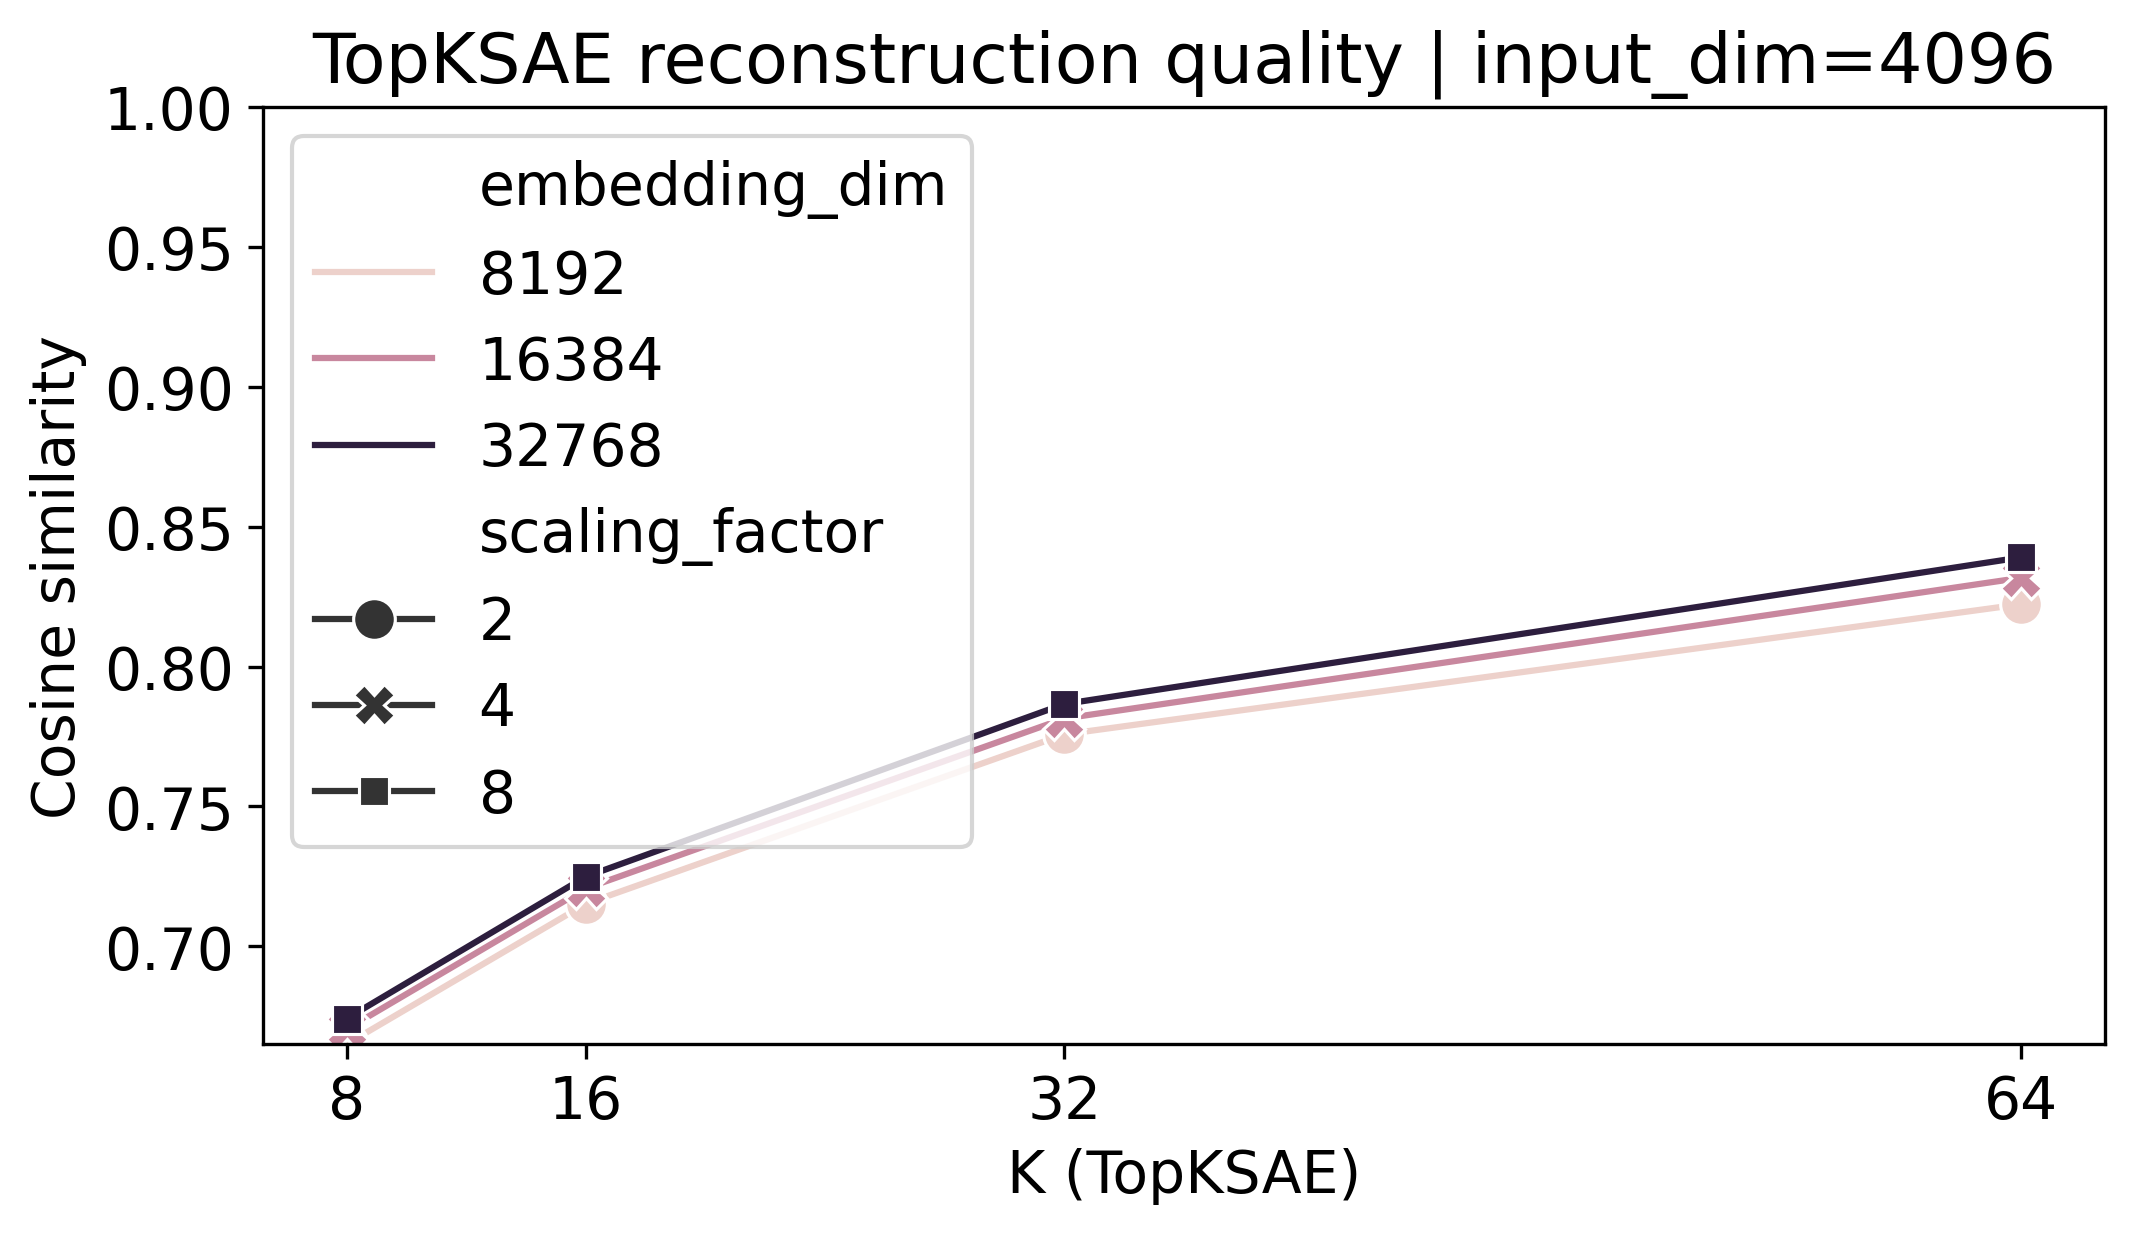

In [20]:
metric = "cosine mean"
plot_df = _df.filter(pl.col("cf_model") == "ELSA").filter(pl.col("model_class").str.starts_with("TopKSAE"))

fig, ax = plt.subplots(1, 1, figsize=(7, 4), constrained_layout=True)
sns.lineplot(
    data=plot_df,
    x="k",
    y=metric,
    hue="embedding_dim",
    style="scaling_factor",
    markers=True,
    dashes=False,
    estimator="mean",
    errorbar=("ci", 95),
    ax=ax,
)
ax.set_xticks(sorted(plot_df.select("k").unique().to_series().to_list()))
ax.set_xlabel("K (TopKSAE)")
ax.set_ylabel("Cosine similarity")
ax.set_ylim(min(0.7, float(plot_df[metric].min())), 1.0)
ax.set_title(f"TopKSAE reconstruction quality | input_dim={input_dim}")

plt.savefig(FIGURES_DIR / f"{dataset}_{split}_dim{input_dim}_{metric.replace(' ', '-')}_topksae.png", bbox_inches="tight")
plt.show()

## Relative Recall

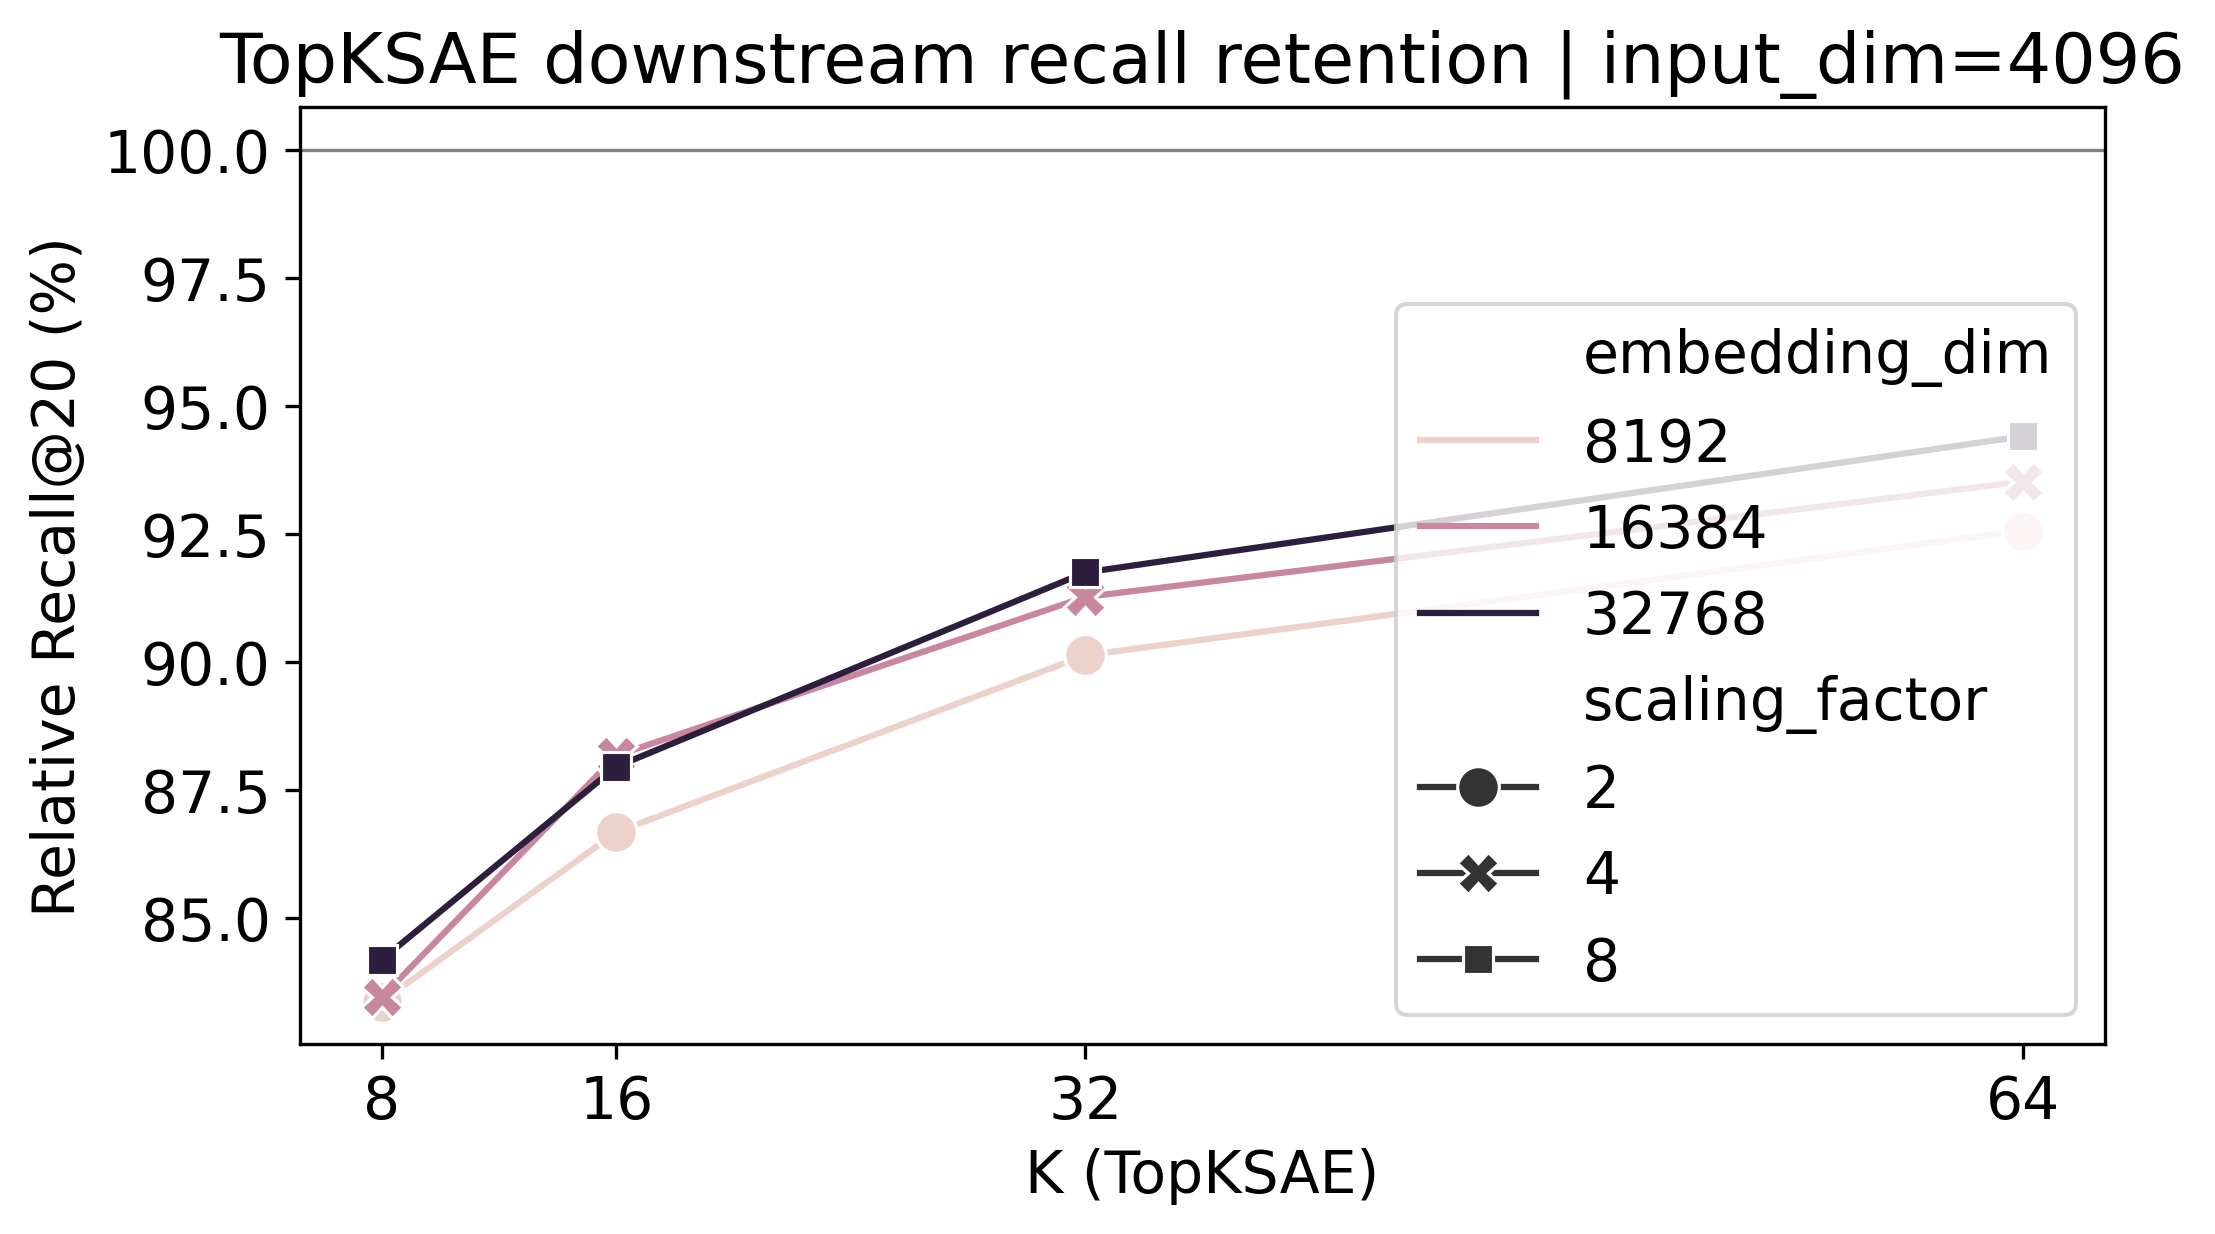

In [21]:
metric = "relative recall"
plot_df = _df.filter(pl.col("cf_model") == "ELSA").filter(pl.col("model_class").str.starts_with("TopKSAE"))

fig, ax = plt.subplots(1, 1, figsize=(7, 4), constrained_layout=True)
sns.lineplot(
    data=plot_df,
    x="k",
    y=metric,
    hue="embedding_dim",
    style="scaling_factor",
    markers=True,
    dashes=False,
    estimator="mean",
    errorbar=("ci", 95),
    ax=ax,
)
ax.axhline(y=100, color="grey", linewidth=0.8)
ax.set_xticks(sorted(plot_df.select("k").unique().to_series().to_list()))
ax.set_xlabel("K (TopKSAE)")
ax.set_ylabel("Relative Recall@20 (%)")
ax.set_title(f"TopKSAE downstream recall retention | input_dim={input_dim}")

plt.savefig(FIGURES_DIR / f"{dataset}_{split}_dim{input_dim}_{metric.replace(' ', '-')}_topksae.png", bbox_inches="tight")
plt.show()

## Relative nDCG

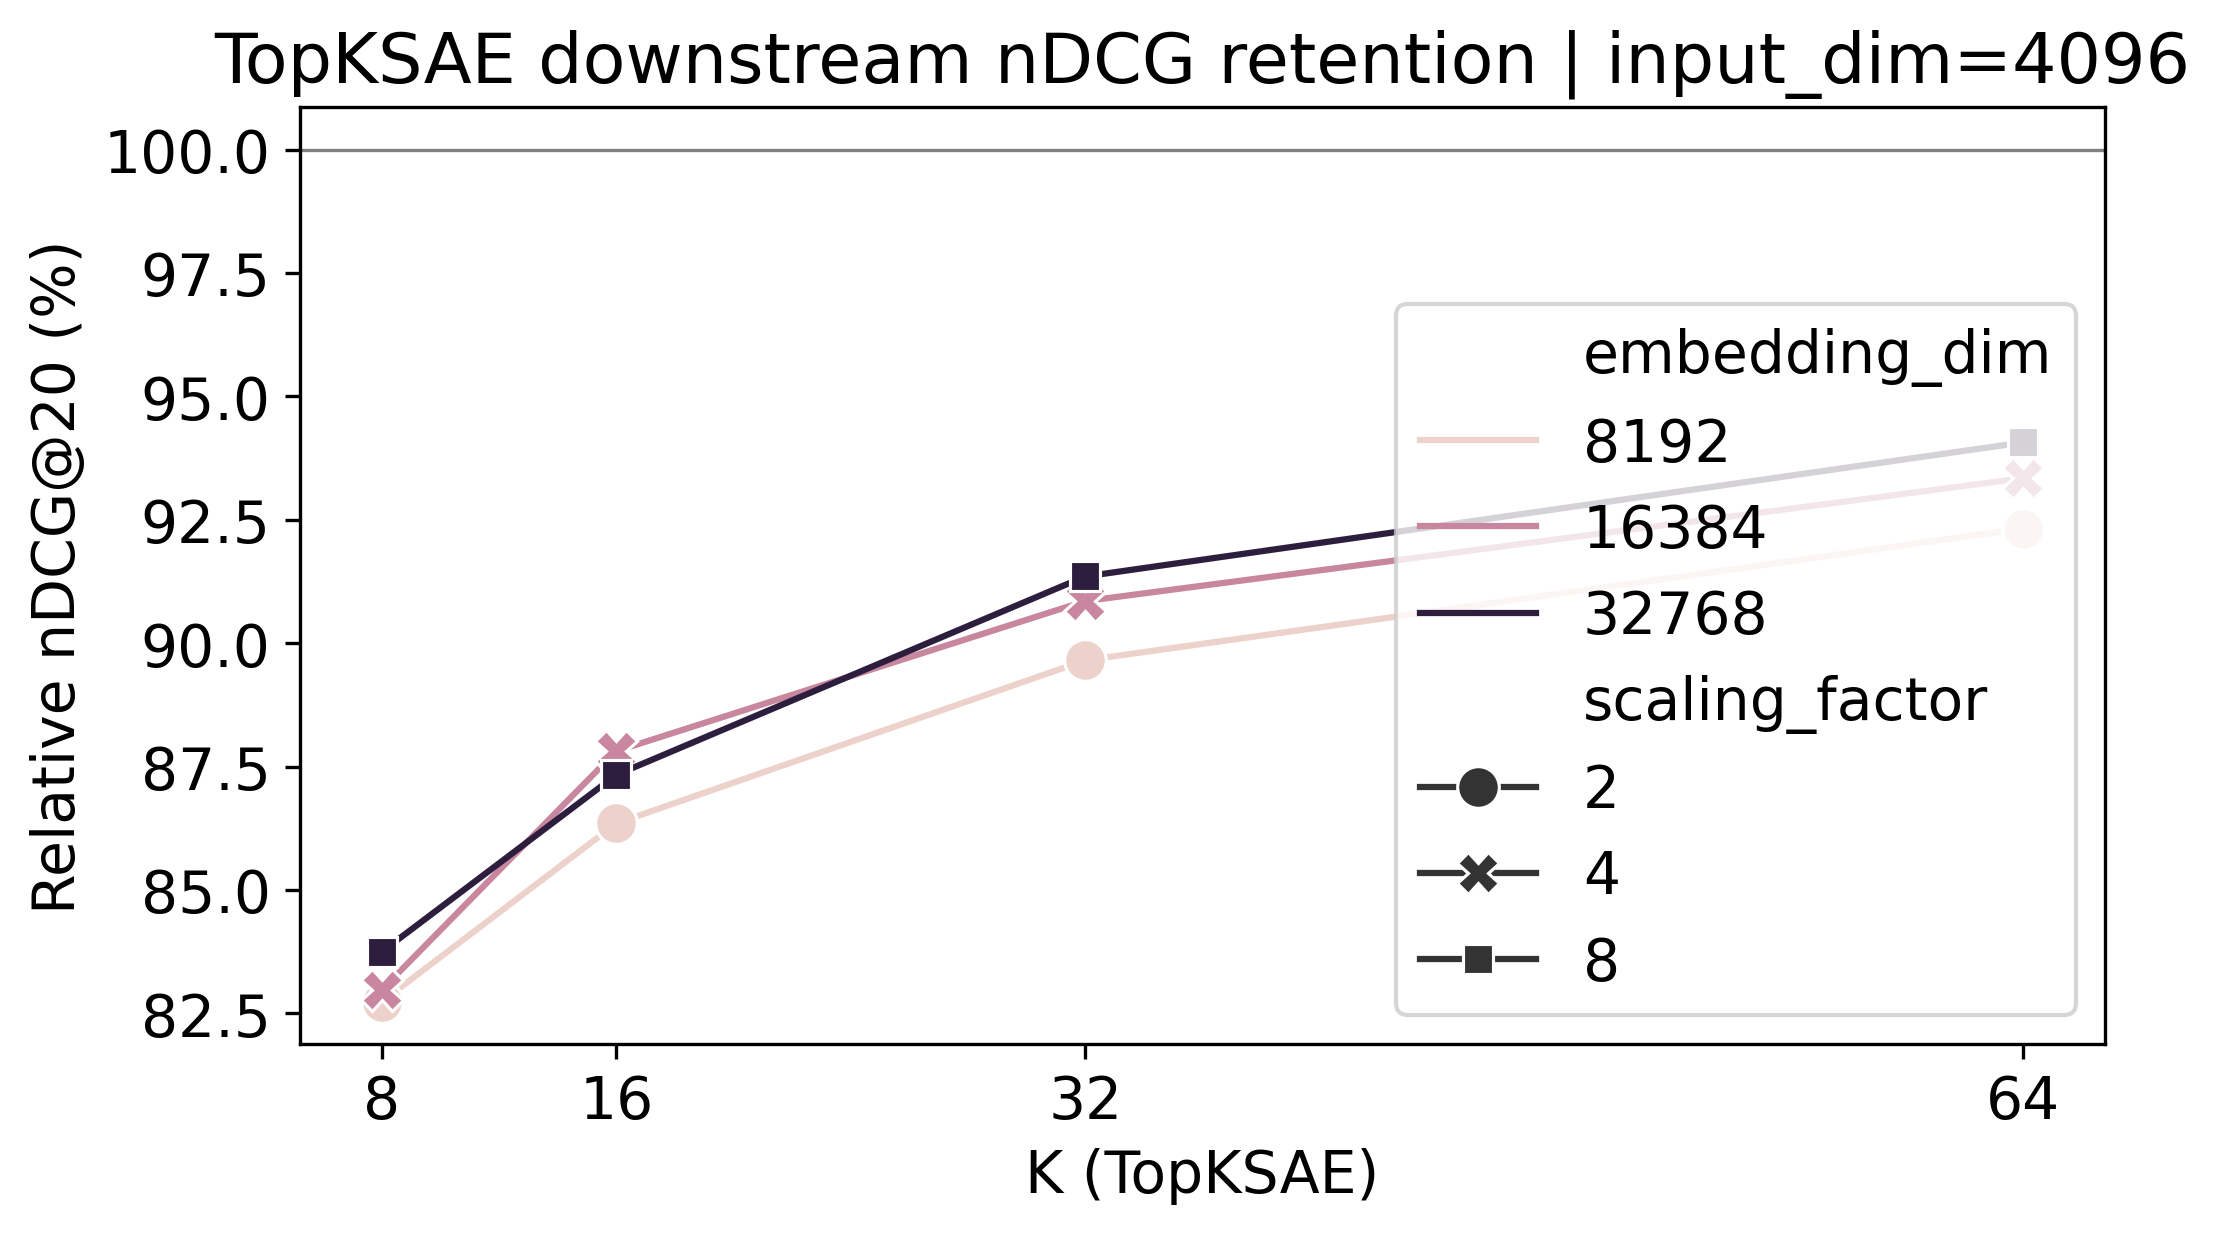

In [22]:
metric = "relative ndcg"
plot_df = _df.filter(pl.col("cf_model") == "ELSA").filter(pl.col("model_class").str.starts_with("TopKSAE"))

fig, ax = plt.subplots(1, 1, figsize=(7, 4), constrained_layout=True)
sns.lineplot(
    data=plot_df,
    x="k",
    y=metric,
    hue="embedding_dim",
    style="scaling_factor",
    markers=True,
    dashes=False,
    estimator="mean",
    errorbar=("ci", 95),
    ax=ax,
)
ax.axhline(y=100, color="grey", linewidth=0.8)
ax.set_xticks(sorted(plot_df.select("k").unique().to_series().to_list()))
ax.set_xlabel("K (TopKSAE)")
ax.set_ylabel("Relative nDCG@20 (%)")
ax.set_title(f"TopKSAE downstream nDCG retention | input_dim={input_dim}")

plt.savefig(FIGURES_DIR / f"{dataset}_{split}_dim{input_dim}_{metric.replace(' ', '-')}_topksae.png", bbox_inches="tight")
plt.show()

In [23]:
result_dataframes[dataset][split]["sae models"].filter(pl.col("input_dim") == 1024).filter(pl.col("model_class") == "TopKSAE (Cosine)").filter(
    pl.col("k") == 32
).sort("recall mean")

checkpoint,dataset,pretrained_model_checkpoint,model_module,model_class,embedding_dim,reconstruction_loss,l1_coef,k,epochs,early_stopping,batch_size,lr,beta1,beta2,seed,cosine mean,cosine se,l0 mean,l0 se,dead neurons,recall mean,recall se,recall degradation mean,recall degradation se,ndcg mean,ndcg se,ndcg degradation mean,ndcg degradation se,input_dim,scaling_factor,cf_model,cf_model_size
str,str,str,str,str,i64,str,f64,i64,i64,i64,i64,f64,f64,f64,i64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i32,str,i32
"""TopKSAE-4096-86effed3.json""","""ml-32m-filtered""","""ELSA-1024-66e73686.ckpt""","""sae""","""TopKSAE (Cosine)""",4096,"""Cosine""",0.0003,32,120,20,1024,0.0003,0.9,0.99,42,0.826737,0.001612,31.999838,0.000161,28,0.343953,0.002518,-0.01893,0.001076,0.350407,0.002602,-0.019302,0.000876,1024,4,"""ELSA""",2
"""TopKSAE-4096-747376d5.json""","""ml-32m-filtered""","""ELSA-1024-7f035e3d.ckpt""","""sae""","""TopKSAE (Cosine)""",4096,"""Cosine""",0.0003,32,250,50,1024,0.0003,0.9,0.99,42,0.823269,0.001741,31.999353,0.000511,21,0.345225,0.002531,-0.025029,0.001166,0.351619,0.002602,-0.026637,0.000978,1024,4,"""ELSA""",2
"""TopKSAE-2048-547f84ee.json""","""ml-32m-filtered""","""ELSA-1024-7f035e3d.ckpt""","""sae""","""TopKSAE (Cosine)""",2048,"""Cosine""",0.0003,32,250,50,1024,0.0003,0.9,0.99,42,0.81985,0.001766,32.0,0.0,2,0.345341,0.002514,-0.024913,0.001155,0.351828,0.002603,-0.026429,0.000984,1024,2,"""ELSA""",2
"""TopKSAE-8192-e626099b.json""","""ml-32m-filtered""","""ELSA-1024-7f035e3d.ckpt""","""sae""","""TopKSAE (Cosine)""",8192,"""Cosine""",0.0003,32,250,50,1024,0.0003,0.9,0.99,42,0.820944,0.00166,31.999353,0.000511,157,0.347533,0.002509,-0.025289,0.001162,0.357555,0.00259,-0.024963,0.000976,1024,8,"""ELSA""",2


In [29]:
dataset = DATASETS[0]
split = "val"

sae_df = result_dataframes[dataset][split]["sae models"].with_columns(
    (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
    (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
)

# Keep only TopKSAE rows for current case clarity.
#sae_df = sae_df.filter(pl.col("model_class").str.starts_with("TopKSAE"))

#cf_baseline_df = result_dataframes[dataset][split]["cf models"].filter(pl.col("model_class") == "ELSA")

FINAL_ONLY = False
sae_df = result_dataframes[dataset][split]["sae models"].with_columns(
    (100 * pl.col("recall mean") / (pl.col("recall mean") - pl.col("recall degradation mean"))).alias("relative recall"),
    (100 * pl.col("ndcg mean") / (pl.col("ndcg mean") - pl.col("ndcg degradation mean"))).alias("relative ndcg"),
).filter(pl.col("model_class").str.starts_with("TopKSAE"))
cf_baseline_df = result_dataframes[dataset][split]["cf models"].filter(pl.col("model_class") == "ELSA")

if FINAL_ONLY:
    sae_df = sae_df.filter(
        (pl.col("epochs") == 250) &
        (pl.col("early_stopping") == 50)
    )
    cf_baseline_df = cf_baseline_df.filter(
        (pl.col("epochs") == 25) &
        (pl.col("early_stopping") == 10)
    )

print("SAE rows:", sae_df.height)
print("CF rows:", cf_baseline_df.height)
sae_df.select(["embedding_dim", "k", "input_dim", "cf_model_size", "l0 mean", "recall mean", "ndcg mean", "ndcg degradation mean"]).sort(["input_dim", "embedding_dim", "k"])

SAE rows: 49
CF rows: 4


embedding_dim,k,input_dim,cf_model_size,l0 mean,recall mean,ndcg mean,ndcg degradation mean
i64,i64,i64,i32,f64,f64,f64,f64
1024,8,512,1,8.0,0.319677,0.325948,-0.044411
1024,16,512,1,16.0,0.339433,0.344109,-0.02625
1024,32,512,1,32.0,0.352038,0.357929,-0.015309
1024,64,512,1,64.0,0.353924,0.360001,-0.010754
2048,8,512,1,8.0,0.323678,0.328247,-0.042111
…,…,…,…,…,…,…,…
16384,64,4096,8,60.483612,0.34816,0.356169,-0.025407
32768,8,4096,8,8.0,0.311789,0.319503,-0.061994
32768,16,4096,8,15.999677,0.327439,0.33249,-0.048229


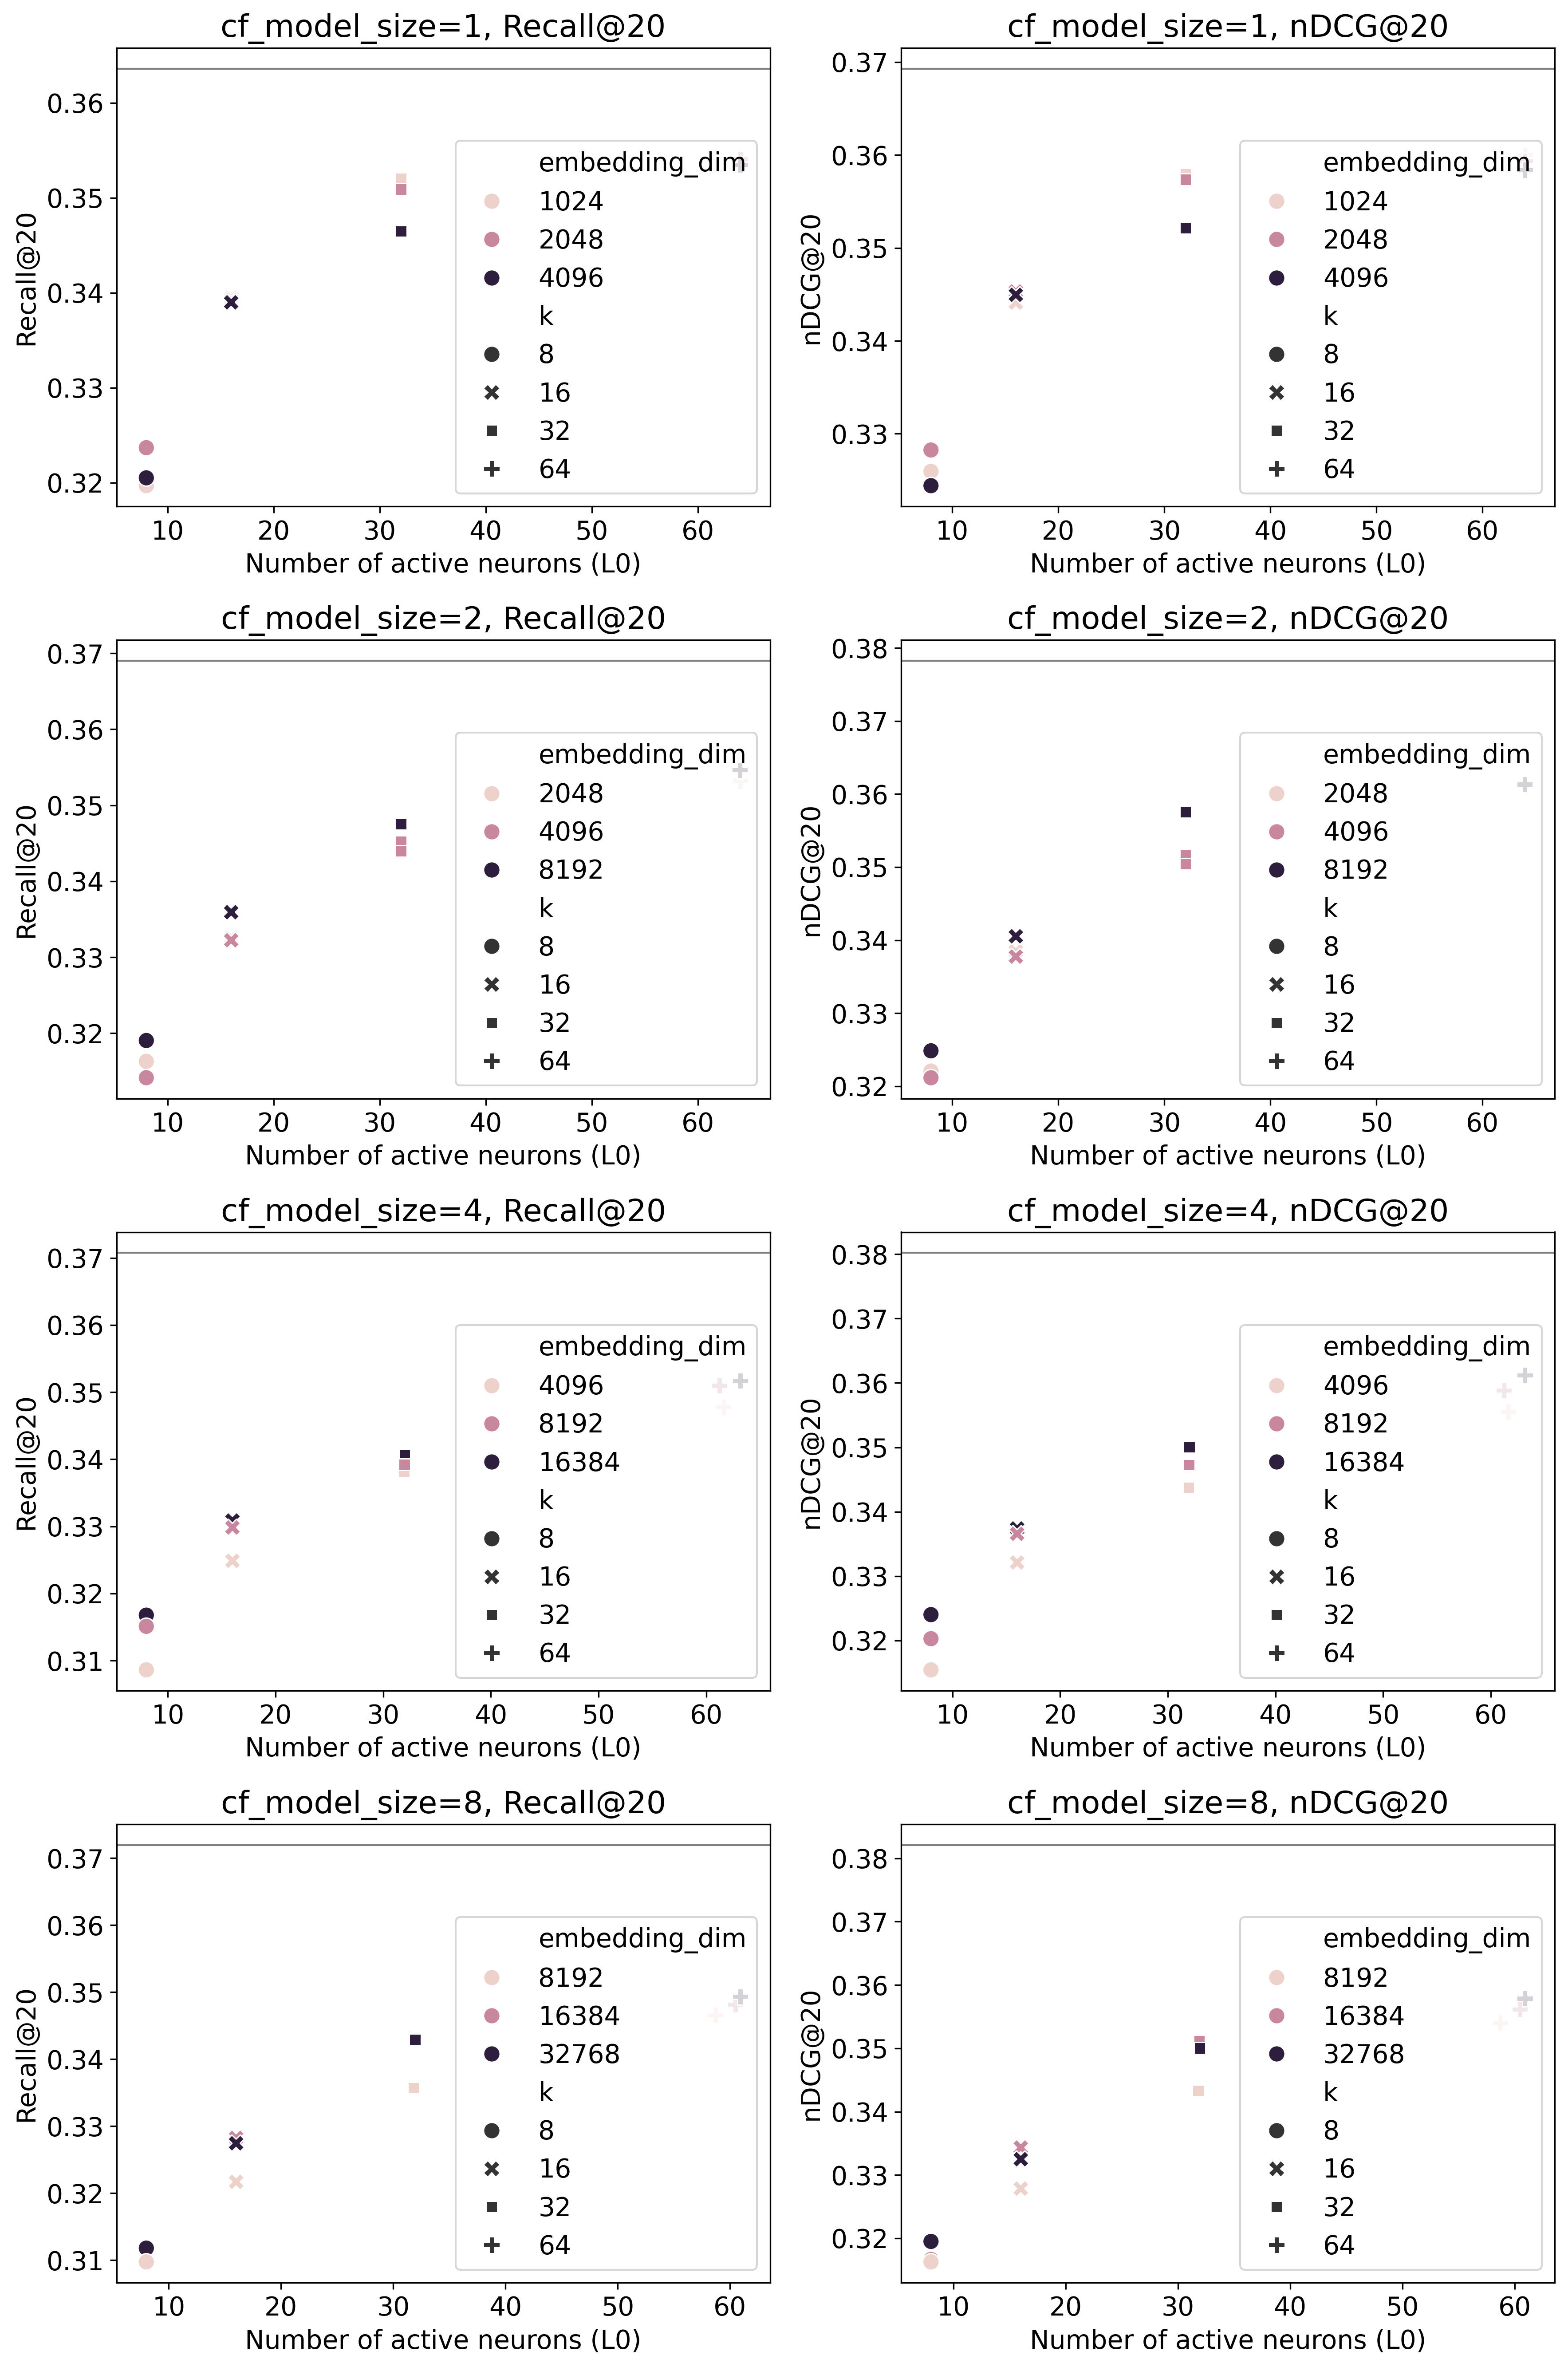

In [30]:
# All TopKSAE points, faceted by cf_model_size
cf_sizes = sorted(sae_df.select("cf_model_size").unique().to_series().to_list())
metrics = [("recall mean", "Recall@20"), ("ndcg mean", "nDCG@20")]

fig, axes = plt.subplots(len(cf_sizes), len(metrics), figsize=(6 * len(metrics), 4.5 * len(cf_sizes)), squeeze=False)

for i, cf_size in enumerate(cf_sizes):
    sub = sae_df.filter(pl.col("cf_model_size") == cf_size)
    baseline_row = cf_baseline_df.filter(pl.col("embedding_dim") == int(cf_size * 512))

    for j, (metric_col, metric_label) in enumerate(metrics):
        ax = axes[i, j]
        sns.scatterplot(
            data=sub,
            x="l0 mean",
            y=metric_col,
            hue="embedding_dim",
            style="k",
            ax=ax,
            s=80,
        )
        if baseline_row.height > 0:
            ax.axhline(float(baseline_row[metric_col][0]), color="grey", linewidth=1)
        ax.set_xlabel("Number of active neurons (L0)")
        ax.set_ylabel(metric_label)
        ax.set_title(f"cf_model_size={cf_size}, {metric_label}")

plt.tight_layout()
plt.show()

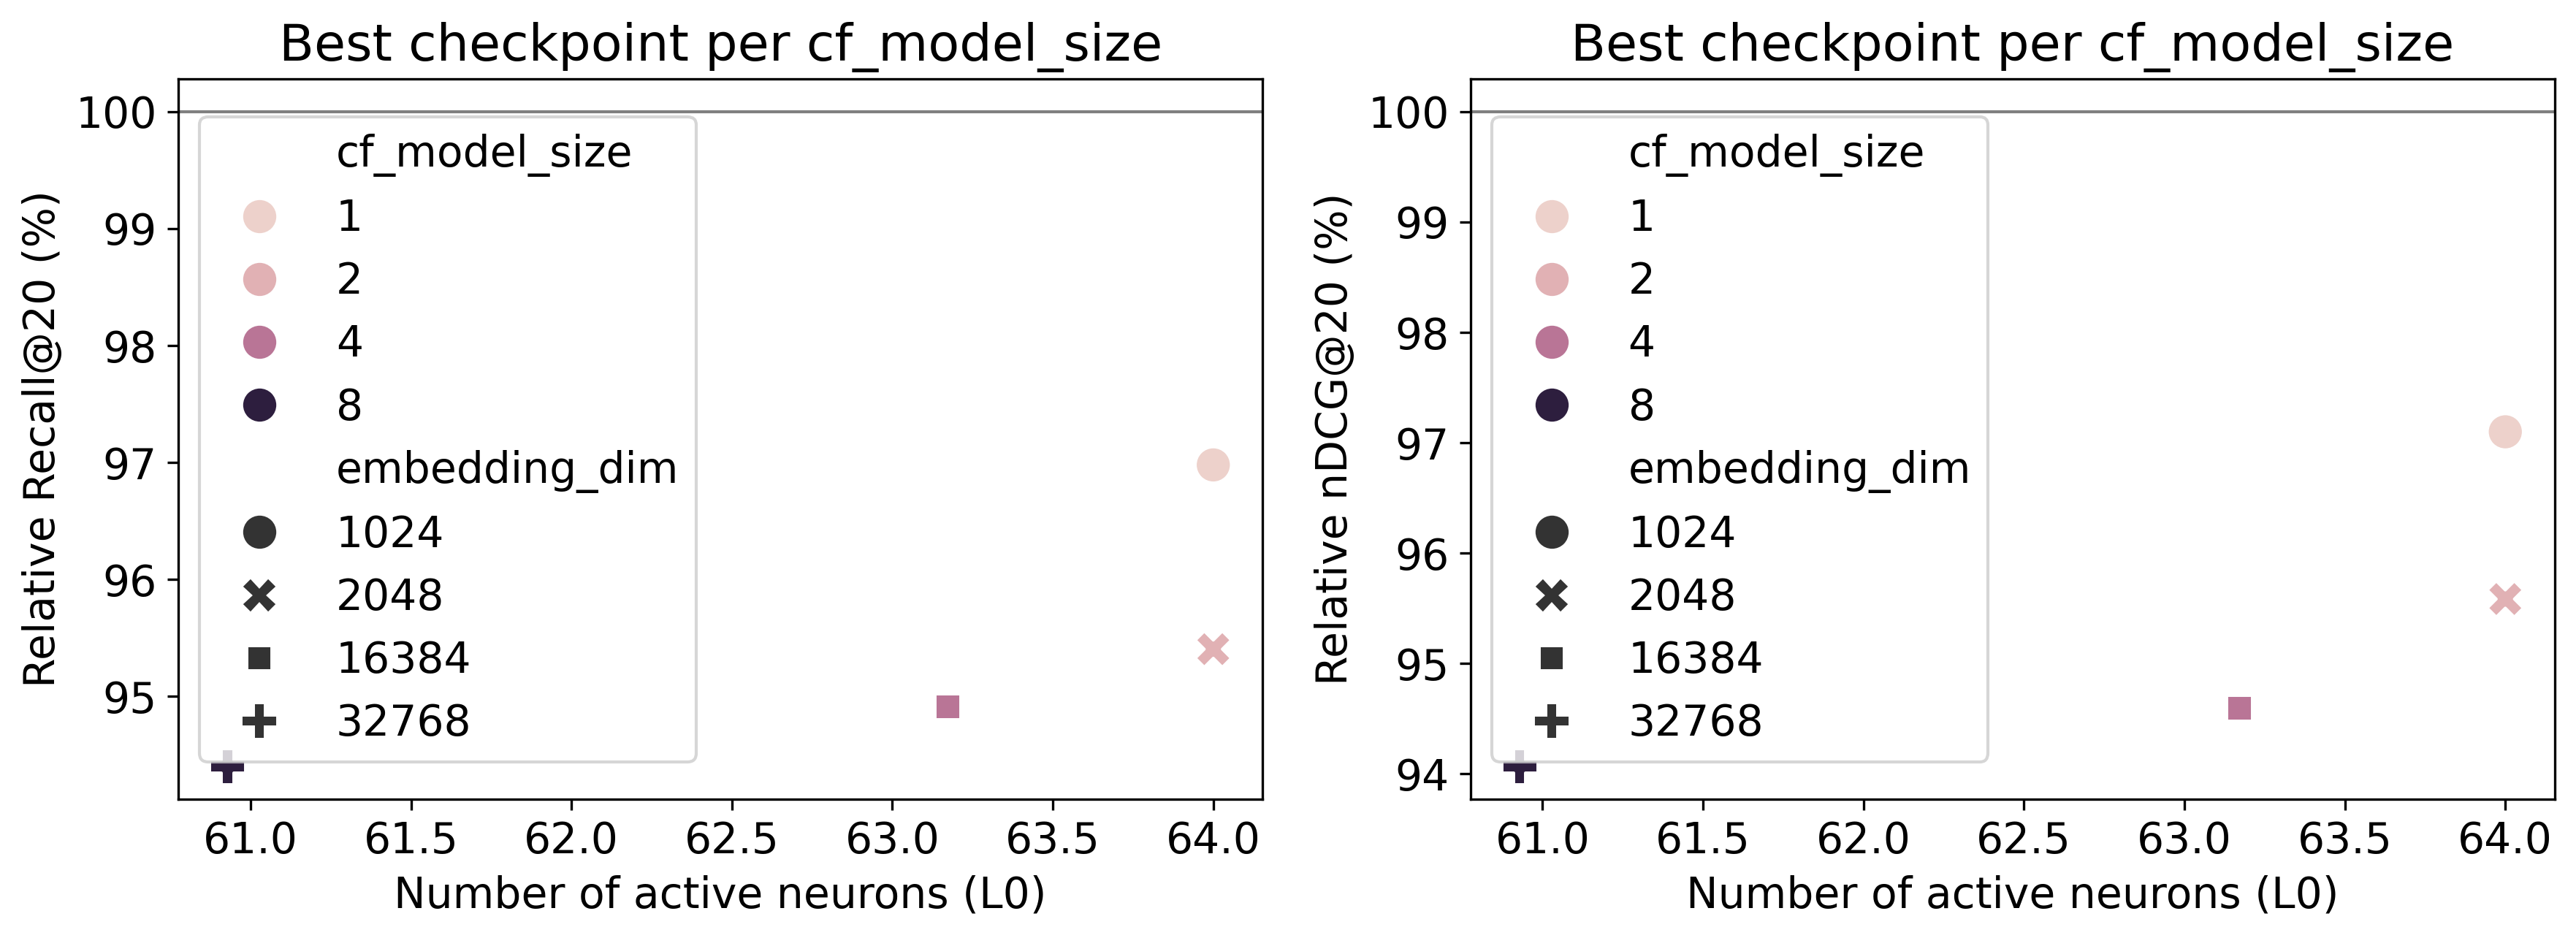

cf_model_size,checkpoint,embedding_dim,k,l0 mean,recall mean,ndcg mean,recall degradation mean,ndcg degradation mean
i32,str,i64,i64,f64,f64,f64,f64,f64
1,"""TopKSAE-1024-77965725.json""",1024,64,64.0,0.353924,0.360001,-0.011022,-0.010754
2,"""TopKSAE-2048-fad92f37.json""",2048,64,64.0,0.35324,0.361554,-0.017014,-0.016703
4,"""TopKSAE-16384-a4f931b4.json""",16384,64,63.172775,0.351676,0.361193,-0.018842,-0.020628
8,"""TopKSAE-32768-5f400454.json""",32768,64,60.928791,0.349339,0.357877,-0.02072,-0.022574


In [31]:
# One checkpoint per cf_model_size (best by ndcg degradation mean, i.e. closest to 0)
best_per_cf = (
    sae_df
    .sort(["cf_model_size", "ndcg degradation mean"], descending=[False, True])
    .group_by("cf_model_size")
    .first()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), squeeze=False)
for j, (metric_col, metric_label) in enumerate([("relative recall", "Relative Recall@20 (%)"), ("relative ndcg", "Relative nDCG@20 (%)")]):
    ax = axes[0, j]
    sns.scatterplot(
        data=best_per_cf,
        x="l0 mean",
        y=metric_col,
        hue="cf_model_size",
        style="embedding_dim",
        ax=ax,
        s=140,
    )
    ax.axhline(100.0, color="grey", linewidth=1)
    ax.set_xlabel("Number of active neurons (L0)")
    ax.set_ylabel(metric_label)
    ax.set_title("Best checkpoint per cf_model_size")

plt.tight_layout()
plt.show()

best_per_cf.select([
    "cf_model_size", "checkpoint", "embedding_dim", "k", "l0 mean", "recall mean", "ndcg mean", "recall degradation mean", "ndcg degradation mean"
]).sort("cf_model_size")

In [32]:
# Primary criterion: max ndcg degradation mean (least negative); tie-breaker: max recall degradation mean.
final_best = (
    sae_df
    .sort(["ndcg degradation mean", "recall degradation mean"], descending=[True, True])
    .head(1)
)

print("Best checkpoint for current case:")
final_best.select([
    "checkpoint",
    "pretrained_model_checkpoint",
    "input_dim",
    "embedding_dim",
    "k",
    "l0 mean",
    "cosine mean",
    "dead neurons",
    "recall mean",
    "recall degradation mean",
    "ndcg mean",
    "ndcg degradation mean",
])

Best checkpoint for current case:


checkpoint,pretrained_model_checkpoint,input_dim,embedding_dim,k,l0 mean,cosine mean,dead neurons,recall mean,recall degradation mean,ndcg mean,ndcg degradation mean
str,str,i64,i64,i64,f64,f64,i64,f64,f64,f64,f64
"""TopKSAE-1024-77965725.json""","""ELSA-512-c2005bb7.ckpt""",512,1024,64,64.0,0.88896,0,0.353924,-0.011022,0.360001,-0.010754


In [36]:
# Steering-oriented selection: keep usable models first, then prefer sparser control.
# Gating thresholds can be relaxed if too strict for a given run set.
MIN_REL_NDCG = 95.0
MIN_REL_RECALL = 95.0
MIN_COSINE = 0.80

steering_candidates = sae_df.filter(
    (pl.col("relative ndcg") >= MIN_REL_NDCG)
    & (pl.col("relative recall") >= MIN_REL_RECALL)
    & (pl.col("cosine mean") >= MIN_COSINE)
)

if steering_candidates.height == 0:
    print("No candidate passed steering gate; falling back to all SAE rows.")
    steering_candidates = sae_df

# Primary objective for steering: as sparse as possible while staying usable.
# Tie-breakers keep recommendation quality high.
final_best_steering = (
    steering_candidates
    .sort(
        ["l0 mean", "ndcg degradation mean", "recall degradation mean", "dead neurons"],
        descending=[False, True, True, False],
    )
    .head(1)
)

print("Best checkpoint for steering-oriented use:")
final_best_steering.select([
    "checkpoint",
    "pretrained_model_checkpoint",
    "input_dim",
    "embedding_dim",
    "k",
    "l0 mean",
    "cosine mean",
    "dead neurons",
    "relative recall",
    "relative ndcg",
    "recall degradation mean",
    "ndcg degradation mean",
])

print("Top 5 steering candidates:")
steering_candidates.sort(
    ["l0 mean", "ndcg degradation mean", "recall degradation mean", "dead neurons"],
    descending=[False, True, True, False],
).head(5).select([
    "checkpoint",
    "pretrained_model_checkpoint",
    "input_dim",
    "embedding_dim",
    "k",
    "l0 mean",
    "cosine mean",
    "dead neurons",
    "relative recall",
    "relative ndcg",
    "ndcg degradation mean",
])

Best checkpoint for steering-oriented use:
Top 5 steering candidates:


checkpoint,pretrained_model_checkpoint,input_dim,embedding_dim,k,l0 mean,cosine mean,dead neurons,relative recall,relative ndcg,ndcg degradation mean
str,str,i64,i64,i64,f64,f64,i64,f64,f64,f64
"""TopKSAE-1024-4d51a427.json""","""ELSA-512-c2005bb7.ckpt""",512,1024,32,32.0,0.866528,0,96.006908,95.898413,-0.015309
"""TopKSAE-2048-d0ec8a89.json""","""ELSA-512-c2005bb7.ckpt""",512,2048,32,32.0,0.8656,0,95.751223,95.852852,-0.015462
"""TopKSAE-8192-b1b5596f.json""","""ELSA-1024-7f035e3d.ckpt""",1024,8192,64,63.965607,0.862118,29,95.782006,95.525251,-0.016926
"""TopKSAE-4096-5d7ef2ad.json""","""ELSA-1024-7f035e3d.ckpt""",1024,4096,64,63.987244,0.862634,0,95.734711,95.55045,-0.016831
"""TopKSAE-1024-77965725.json""","""ELSA-512-c2005bb7.ckpt""",512,1024,64,64.0,0.88896,0,96.979936,97.099446,-0.010754


In [35]:
"""
gate na použitelnost:
relative ndcg >= 95
relative recall >= 95
cosine >= 0.80
když gate nic nevrátí, fallbackne na všechny SAE řádky
pak vybere final_best_steering podle:
co nejnižší l0 mean
co nejvyšší ndcg degradation mean (tj. nejmíň negativní)
co nejvyšší recall degradation mean
co nejméně dead neurons
"""

'\nHotovo — do další buňky v training_run_results.ipynb jsem přidal steering-oriented výběr.\n\nCo nová buňka dělá:\n\nnastaví gate na použitelnost:\nrelative ndcg >= 95\nrelative recall >= 95\ncosine >= 0.80\nkdyž gate nic nevrátí, fallbackne na všechny SAE řádky\npak vybere final_best_steering podle:\nco nejnižší l0 mean\nco nejvyšší ndcg degradation mean (tj. nejmíň negativní)\nco nejvyšší recall degradation mean\nco nejméně dead neurons\nvypíše i Top 5 steering kandidátů\nNavíc jsem ověřil, že notebook po úpravě syntakticky sedí (all code cells compile).\n'